# Rescorla–Wagner Model Identifiability Walkthrough

This notebook is a literate and reproducible companion to the ICCCI 2026 paper:

**When Interpretable Parameters Fail to Explain: Evidence from the Rescorla–Wagner Model**

The goal is twofold:

1. to introduce the elementary components of the Rescorla-Wagner reinforcement-learning model step by step,
2. to reproduce the simulation diagnostics used in the paper for assessing whether fitted parameters can support reliable mechanistic explanations.

The notebook starts from small algorithmic building blocks, such as value updating, stochastic choice, likelihood evaluation, and maximum-likelihood identification. These components are then combined into higher-level diagnostic procedures: likelihood-geometry analysis, boundary-hit diagnostics, parameter recovery, scaled vector error, and overlap analysis of recovered parameter distributions.

Computationally expensive simulations generate intermediate artifacts that can be reused by later lightweight plotting and analysis sections.

## How to read this notebook

The notebook is organized in layers:

1. basic model components,
2. maximum-likelihood identification,
3. diagnostic quantities,
4. computationally expensive simulations,
5. lightweight plotting and analysis from generated artifacts.

Sections marked as **HEAVY** may take longer to run and generate intermediate files. Sections marked as **LIGHT** load previously generated artifacts and recreate figures or summaries.

## Notebook setup

### Visualization settings for publication-quality figures

This section defines a consistent `matplotlib` style used throughout the notebook.  
The goal is to make all diagnostic figures visually consistent, readable, and suitable for publication or inspection.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


# Directory for generated figures.
FIGURES_DIR = Path("artifacts") / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def set_publication_style() -> None:
    """
    Set a consistent Matplotlib style for figures used in this notebook.

    Notes
    -----
    This function only defines global visual defaults. It does not impose
    plot-specific colors, markers, labels, or limits, which should remain
    explicit in the individual plotting sections.
    """
    plt.rcParams.update({
        # Figure and saving
        "figure.figsize": (6.0, 4.2),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",

        # Layout
        "figure.constrained_layout.use": True,

        # Typography
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "axes.titlepad": 8,
        "axes.labelpad": 6,

        # Axes and ticks
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,

        # Grid
        "grid.alpha": 0.25,
        "grid.linestyle": "-",

        # Lines and markers
        "lines.linewidth": 1.5,
        "lines.markersize": 4,

        # Legend
        "legend.frameon": False,

        # Math formatting
        "mathtext.fontset": "stix",
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": True,

        # More editable vector output
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def set_nice_ticks(ax, max_ticks: int = 6) -> None:
    """
    Keep tick density readable and consistent across simple numeric plots.

    This helper is intended for standard linear axes. For heatmaps, colorbars,
    categorical axes, or log-scaled axes, ticks should usually be handled
    explicitly in the corresponding plotting function.
    """
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_ticks))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=max_ticks))


def save_figure(fig, filename: str, *, dpi: int = 300) -> Path:
    """
    Save a figure to the shared figures directory and return the output path.
    """
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=dpi)
    return output_path


set_publication_style()

### Reproducibility and output directories

In [2]:
from pathlib import Path
import numpy as np

# SEED = 314
# rng = np.random.default_rng(SEED)

ARTIFACTS_DIR = Path("artifacts")
RAW_DIR = ARTIFACTS_DIR / "raw"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
METADATA_DIR = ARTIFACTS_DIR / "metadata"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

for directory in [RAW_DIR, FIGURES_DIR, METADATA_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

## Numerical building blocks

### Numerically stable sigmoid and log-sigmoid utilities

The choice rule and likelihood calculations rely on logistic transformations.  
Before defining the Rescorla-Wagner agent, we introduce numerically stable sigmoid and log-sigmoid utilities. These functions avoid overflow and underflow in later likelihood computations.

In [3]:
import numpy as np

# ---------------------------------------------------------------------
# Numerically stable logistic utilities
# ---------------------------------------------------------------------
#
# These functions are used later in the softmax-based choice rule and in
# trial-wise log-likelihood calculations.
#
# For large positive or negative logits, naive expressions such as
#
#     1 / (1 + exp(-z))
#     log(sigmoid(z))
#     log(1 - sigmoid(z))
#
# may suffer from overflow, underflow, or loss of precision. The utilities
# below avoid these numerical issues.


def stable_sigmoid(z):
    """
    Compute sigmoid(z) in a numerically stable way.

    Supports both scalar inputs and NumPy arrays.
    """
    z_arr = np.asarray(z, dtype=float)
    out = np.empty_like(z_arr, dtype=float)

    positive = z_arr >= 0
    negative = ~positive

    out[positive] = 1.0 / (1.0 + np.exp(-z_arr[positive]))

    exp_z = np.exp(z_arr[negative])
    out[negative] = exp_z / (1.0 + exp_z)

    return float(out) if np.isscalar(z) else out


def stable_log_sigmoid(z):
    """
    Compute log(sigmoid(z)) in a numerically stable way.

    This scalar version is intended for trial-wise log-likelihood terms.
    """
    z = float(z)

    if z >= 0:
        return -np.log1p(np.exp(-z))

    return z - np.log1p(np.exp(z))


def stable_log1m_sigmoid(z):
    """
    Compute log(1 - sigmoid(z)) in a numerically stable way.

    Since 1 - sigmoid(z) = sigmoid(-z), this is equivalent to:

        log(sigmoid(-z))

    but is written explicitly for readability in binary choice likelihoods.
    """
    z = float(z)

    if z >= 0:
        return -z - np.log1p(np.exp(-z))

    return -np.log1p(np.exp(z))


# ---------------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------------
#
# These checks are intentionally lightweight. They verify that the utility
# functions return finite values and satisfy key logistic identities.

test_logits = np.array([-20, -5, -1, 0, 1, 5, 20], dtype=float)

p = stable_sigmoid(test_logits)
log_p = np.array([stable_log_sigmoid(z) for z in test_logits])
log_1m_p = np.array([stable_log1m_sigmoid(z) for z in test_logits])

assert np.all(np.isfinite(p))
assert np.all(np.isfinite(log_p))
assert np.all(np.isfinite(log_1m_p))

# Basic range check for probabilities.
assert np.all((p > 0.0) & (p < 1.0))

# Logistic identities.
assert np.allclose(log_p, np.log(p), rtol=0.0, atol=1e-12)
assert np.allclose(log_1m_p, np.array([stable_log_sigmoid(-z) for z in test_logits]), rtol=0.0, atol=1e-12)

print("Stable sigmoid utilities: sanity checks passed.")

Stable sigmoid utilities: sanity checks passed.


## Rescorla–Wagner behavioral model

### Learning and stochastic choice

The numerical utilities introduced in the previous section are now used to construct the complete behavioral model.

The model consists of two conceptually distinct components:

- value learning using the Rescorla–Wagner update rule,
- stochastic action selection using the softmax choice rule.

These two mechanisms constitute the computational agent used throughout the remainder of this notebook.

In [4]:
import numpy as np

# ---------------------------------------------------------------------
# Expected player-model interface
# ---------------------------------------------------------------------
#
# Throughout this notebook, a behavioral model is expected to provide:
#
#   - init_state()
#   - choice_probabilities(state, params)
#   - choice_log_probabilities(state, params)
#   - update_state(state, choice, reward, params)
#
# This interface separates the simulation and fitting pipeline from any
# particular behavioral model. The Rescorla–Wagner model below is one
# concrete implementation.
#
# Conventions
# -----------
# - choice is encoded as 0=A, 1=B
# - reward is binary: 0/1
# - state is a NumPy array of action values
#
# Important modeling convention
# -----------------------------
# Parameter constraints belong to inference procedures rather than to the
# behavioral model itself. Therefore, the functions below do not enforce
# bounds on alpha or T. Interpretability constraints and optimization
# bounds are introduced later, when defining simulation and identification
# procedures.

# ---------------------------------------------------------------------
# Rescorla–Wagner model
# ---------------------------------------------------------------------

def rw_init_state():
    """Initialize RW state: Q-values for actions A and B."""
    return np.zeros(2, dtype=float)


def rw_choice_logit(state, params):
    """
    Compute the logit for choosing A under a two-action softmax rule:

        z = (Q_A - Q_B) / T

    Notes
    -----
    The temperature parameter T is typically interpreted as positive.
    This function does not enforce that constraint programmatically.
    Bounds on T are handled later by the simulation or inference procedure.
    """
    Q = np.asarray(state, dtype=float)
    T = params["T"]

    return (Q[0] - Q[1]) / T


def rw_choice_probabilities(state, params):
    """
    Return choice probabilities [P(A), P(B)] under the sigmoid choice rule:

        P(A) = sigmoid((Q_A - Q_B) / T)
    """
    z = rw_choice_logit(state, params)
    p_a = float(stable_sigmoid(z))

    return np.array([p_a, 1.0 - p_a], dtype=float)


def rw_choice_log_probabilities(state, params):
    """
    Return log choice probabilities [log P(A), log P(B)].

    The probabilities are computed directly in log-space for numerical
    stability and are used later in likelihood calculations.
    """
    z = rw_choice_logit(state, params)

    return np.array(
        [stable_log_sigmoid(z), stable_log1m_sigmoid(z)],
        dtype=float,
    )


def rw_update_state(state, choice, reward, params):
    """
    Apply the Rescorla–Wagner update to the chosen action:

        Q_c <- Q_c + alpha * (reward - Q_c)

    Notes
    -----
    The learning-rate parameter alpha is commonly interpreted in the range
    0 <= alpha <= 1. This function does not enforce that range because
    parameter constraints are part of the simulation or inference procedure,
    not the behavioral model itself.

    This function returns a new state and does not modify the input state
    in place.
    """
    alpha = params["alpha"]

    new_state = np.asarray(state, dtype=float).copy()
    new_state[choice] += alpha * (reward - new_state[choice])

    return new_state


# ---------------------------------------------------------------------
# Select active player model
# ---------------------------------------------------------------------
#
# Later simulation and fitting code uses these generic function names.
# To test another behavioral model, replace the assignments below.

init_state = rw_init_state
choice_probabilities = rw_choice_probabilities
choice_log_probabilities = rw_choice_log_probabilities
update_state = rw_update_state

## Experiment configuration

### Global settings shared across the notebook

In [5]:
from dataclasses import dataclass
from pathlib import Path


# ---------------------------------------------------------------------
# Global experiment configuration
# ---------------------------------------------------------------------
#
# This cell defines settings shared across the notebook.
#
# Experiment-specific settings, such as grid size, number of random draws,
# or number of overlap replications, are introduced later next to the
# corresponding experiment.
#
# This keeps the notebook readable: global assumptions are declared here,
# while local experimental design choices remain close to the code that
# uses them.


@dataclass(frozen=True)
class TaskConfig:
    """
    Configuration of the two-option probabilistic learning task.
    """
    reward_prob_A: float = 0.7
    reward_prob_B: float = 0.3
    n_trials: int = 80


@dataclass(frozen=True)
class IdentificationConfig:
    """
    Configuration of the maximum-likelihood identification procedure.

    Parameter constraints belong to inference procedures rather than to
    the behavioral model itself. Therefore, bounds are specified here,
    not inside the Rescorla–Wagner model functions.
    """
    alpha_bounds: tuple[float, float] = (0.001, 0.999)
    temperature_bounds: tuple[float, float] = (0.05, 5.0)
    optimizer: str = "L-BFGS-B"
    boundary_tolerance: float = 1e-3


@dataclass(frozen=True)
class RepeatedSimulationConfig:
    """
    Default configuration for the first repeated-simulation diagnostic.
    """
    true_alpha: float = 0.3
    true_temperature: float = 0.7
    n_replications: int = 200


@dataclass(frozen=True)
class ArtifactConfig:
    """
    Output directories for generated artifacts.
    """
    root: Path = Path("artifacts")
    raw: Path = Path("artifacts") / "raw"
    metadata: Path = Path("artifacts") / "metadata"
    metrics: Path = Path("artifacts") / "metrics"
    figures: Path = Path("artifacts") / "figures"


@dataclass(frozen=True)
class NotebookConfig:
    """
    Global configuration shared by the notebook.
    """
    seed: int = 271828
    task: TaskConfig = TaskConfig()
    identification: IdentificationConfig = IdentificationConfig()
    repeated_simulation: RepeatedSimulationConfig = RepeatedSimulationConfig()
    artifacts: ArtifactConfig = ArtifactConfig()


CONFIG = NotebookConfig()


# Create artifact directories used throughout the notebook.
for directory in [
    CONFIG.artifacts.raw,
    CONFIG.artifacts.metadata,
    CONFIG.artifacts.metrics,
    CONFIG.artifacts.figures,
]:
    directory.mkdir(parents=True, exist_ok=True)


# Convenience aliases used in later cells.
SEED = CONFIG.seed

P_REWARD_A = CONFIG.task.reward_prob_A
P_REWARD_B = CONFIG.task.reward_prob_B
N_TRIALS = CONFIG.task.n_trials

ALPHA_BOUNDS = CONFIG.identification.alpha_bounds
T_BOUNDS = CONFIG.identification.temperature_bounds
BOUNDARY_TOL = CONFIG.identification.boundary_tolerance

TRUE_PARAMS_REPEATED = {
    "alpha": CONFIG.repeated_simulation.true_alpha,
    "T": CONFIG.repeated_simulation.true_temperature,
}
REPEATED_SIM = CONFIG.repeated_simulation
N_REPEATED = CONFIG.repeated_simulation.n_replications

RAW_DIR = CONFIG.artifacts.raw
METADATA_DIR = CONFIG.artifacts.metadata
METRICS_DIR = CONFIG.artifacts.metrics
FIGURES_DIR = CONFIG.artifacts.figures


print("Global notebook configuration initialized.")
print(CONFIG)

Global notebook configuration initialized.
NotebookConfig(seed=271828, task=TaskConfig(reward_prob_A=0.7, reward_prob_B=0.3, n_trials=80), identification=IdentificationConfig(alpha_bounds=(0.001, 0.999), temperature_bounds=(0.05, 5.0), optimizer='L-BFGS-B', boundary_tolerance=0.001), repeated_simulation=RepeatedSimulationConfig(true_alpha=0.3, true_temperature=0.7, n_replications=200), artifacts=ArtifactConfig(root=WindowsPath('artifacts'), raw=WindowsPath('artifacts/raw'), metadata=WindowsPath('artifacts/metadata'), metrics=WindowsPath('artifacts/metrics'), figures=WindowsPath('artifacts/figures')))


## Model sanity checks

### Simulating a single behavioral trajectory

Before developing likelihood-based identification and large-scale simulation studies, we verify that the behavioral model produces sensible learning dynamics on a single realization of the task.

This section has three goals:

1. define a reusable function for simulating one choice–outcome sequence,
2. generate one trajectory using the active behavioral model,
3. visualize the resulting learning dynamics.

This is not yet a parameter-recovery experiment. It is a basic sanity check showing that the model, task, and configuration work together as intended.


In [6]:
def simulate_choice_outcome_sequence(params, n_trials=N_TRIALS, rng=None):
    """
    Simulate one choice-outcome sequence from the active player model.

    Parameters
    ----------
    params : dict
        Model parameters, e.g. {"alpha": ..., "T": ...}.
    n_trials : int
        Number of trials in the simulated task.
    rng : np.random.Generator or None
        Random number generator. If None, a new generator is created.

    Returns
    -------
    dict
        Simulated choices, rewards, Q-value history, choice-probability
        history, and model parameters.
    """
    if rng is None:
        rng = np.random.default_rng()

    state = init_state()

    choices = np.empty(n_trials, dtype=int)
    rewards = np.empty(n_trials, dtype=int)
    q_history = np.empty((n_trials + 1, 2), dtype=float)
    p_history = np.empty((n_trials, 2), dtype=float)

    q_history[0] = state

    for trial in range(n_trials):
        probs = choice_probabilities(state, params)

        choice = rng.choice([0, 1], p=probs)

        reward_prob = P_REWARD_A if choice == 0 else P_REWARD_B
        reward = int(rng.random() < reward_prob)

        choices[trial] = choice
        rewards[trial] = reward
        p_history[trial] = probs

        state = update_state(state, choice, reward, params)
        q_history[trial + 1] = state

    return {
        "choices": choices,
        "rewards": rewards,
        "q_history": q_history,
        "p_history": p_history,
        "params": params,
        "n_trials": n_trials,
        "reward_probabilities": {
            "A": P_REWARD_A,
            "B": P_REWARD_B,
        },
    }

We now generate one trajectory using the default parameters used for the first repeated-simulation diagnostic. The purpose is only to inspect whether the simulated agent produces plausible choices, rewards, action values, and choice probabilities.

In [7]:
rng = np.random.default_rng(SEED)

single_trajectory = simulate_choice_outcome_sequence(
    params=TRUE_PARAMS_REPEATED,
    n_trials=N_TRIALS,
    rng=rng,
)

choice_counts = np.bincount(single_trajectory["choices"], minlength=2)
reward_counts = np.bincount(single_trajectory["rewards"], minlength=2)
final_q_values = single_trajectory["q_history"][-1]

print(f"Generated trials: {single_trajectory['n_trials']}")
print(f"Choice counts: A={choice_counts[0]}, B={choice_counts[1]}")
print(f"Reward counts: reward=0 -> {reward_counts[0]}, reward=1 -> {reward_counts[1]}")
print(f"Final Q-values: Q_A={final_q_values[0]:.3f}, Q_B={final_q_values[1]:.3f}")

Generated trials: 80
Choice counts: A=57, B=23
Reward counts: reward=0 -> 36, reward=1 -> 44
Final Q-values: Q_A=0.345, Q_B=0.005


The plot below shows how the agent's internal action values and choice probabilities evolve during the task. This provides a qualitative check of the learning and decision rules before moving to likelihood-based identification.

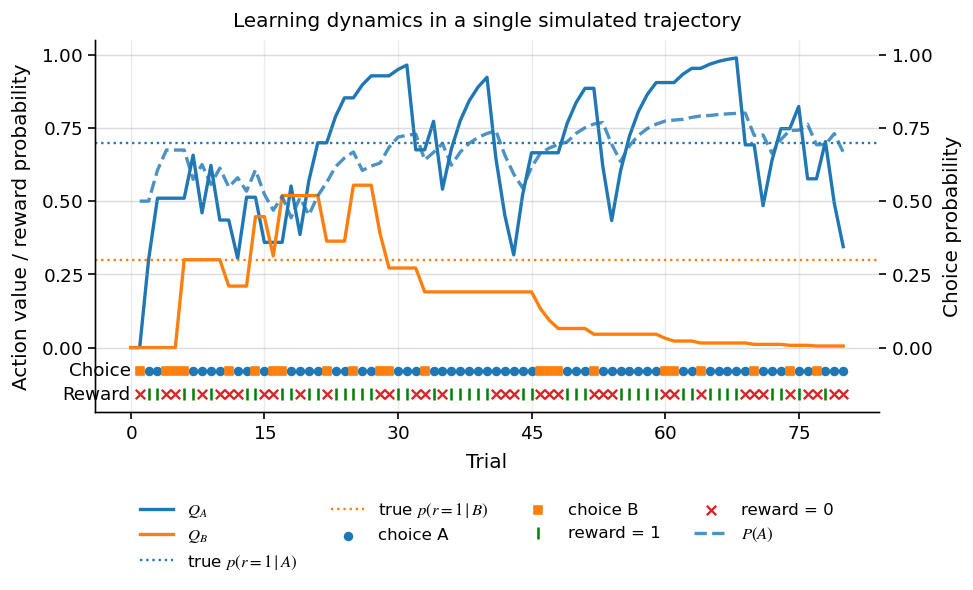

In [8]:
def plot_single_trajectory(trajectory):
    """
    Plot Q-value dynamics, choice probability, choices, and rewards
    for one simulated behavioral trajectory.
    """
    choices = trajectory["choices"]
    rewards = trajectory["rewards"]
    q_history = trajectory["q_history"]
    p_history = trajectory["p_history"]
    reward_probs = trajectory["reward_probabilities"]
    n_trials = trajectory["n_trials"]

    trial_axis_q = np.arange(n_trials + 1)
    trial_axis = np.arange(1, n_trials + 1)

    fig, ax = plt.subplots(figsize=(8.0, 4.8))

    # Q-value trajectories.
    line_qA, = ax.plot(
        trial_axis_q,
        q_history[:, 0],
        linestyle="-",
        linewidth=2.0,
        label=r"$Q_A$",
    )
    line_qB, = ax.plot(
        trial_axis_q,
        q_history[:, 1],
        linestyle="-",
        linewidth=2.0,
        label=r"$Q_B$",
    )

    # True reward probabilities as reference lines.
    ax.axhline(
        reward_probs["A"],
        linestyle=":",
        linewidth=1.4,
        color=line_qA.get_color(),
        label=r"true $p(r=1\mid A)$",
    )
    ax.axhline(
        reward_probs["B"],
        linestyle=":",
        linewidth=1.4,
        color=line_qB.get_color(),
        label=r"true $p(r=1\mid B)$",
    )

    ax.set_xlabel("Trial")
    ax.set_ylabel("Action value / reward probability")
    ax.set_ylim(-0.22, 1.05)

    # Choice probability on the right axis.
    ax_prob = ax.twinx()
    ax_prob.plot(
        trial_axis,
        p_history[:, 0],
        linestyle="--",
        linewidth=2.0,
        alpha=0.8,
        color=line_qA.get_color(),
        label=r"$P(A)$",
    )
    ax_prob.set_ylabel("Choice probability")
    ax_prob.set_ylim(-0.22, 1.05)

    # Trial-level markers below the main plot.
    choice_y = -0.08
    reward_y = -0.16

    choices_A = choices == 0
    choices_B = choices == 1
    rewarded = rewards == 1
    unrewarded = rewards == 0

    ax.scatter(
        trial_axis[choices_A],
        np.full(np.sum(choices_A), choice_y),
        marker="o",
        s=22,
        color=line_qA.get_color(),
        label="choice A",
        clip_on=False,
    )
    ax.scatter(
        trial_axis[choices_B],
        np.full(np.sum(choices_B), choice_y),
        marker="s",
        s=22,
        color=line_qB.get_color(),
        label="choice B",
        clip_on=False,
    )

    ax.scatter(
        trial_axis[rewarded],
        np.full(np.sum(rewarded), reward_y),
        marker="|",
        s=60,
        linewidths=1.5,
        color="green",
        label="reward = 1",
        clip_on=False,
    )
    ax.scatter(
        trial_axis[unrewarded],
        np.full(np.sum(unrewarded), reward_y),
        marker="x",
        s=32,
        linewidths=1.4,
        color="tab:red",
        label="reward = 0",
        clip_on=False,
    )

    ax.text(0, choice_y, "Choice", ha="right", va="center")
    ax.text(0, reward_y, "Reward", ha="right", va="center")

    # Combined legend.
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax_prob.get_legend_handles_labels()
    ax.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=4,
    )

    ax.set_title("Learning dynamics in a single simulated trajectory")

    set_nice_ticks(ax)
    set_nice_ticks(ax_prob)

    return fig


fig = plot_single_trajectory(single_trajectory)
save_figure(fig, "single_behavioral_trajectory.png")
plt.show()

## Likelihood-based parameter identification

### Computing the log-likelihood of a behavioral trajectory

The simulated trajectory generated in the previous section serves as an example dataset.

Given a candidate parameter vector, we compute the log-likelihood of the observed sequence of choices and rewards under the behavioral model. This is the fundamental quantity used later for maximum-likelihood estimation and all subsequent identifiability analyses.

In [9]:
def trajectory_log_likelihood(trajectory, params):
    """
    Compute the log-likelihood of an observed choice sequence
    under the active behavioral model and candidate parameters.

    The reward sequence is treated as observed feedback that drives
    the model's internal state updates. The likelihood is computed
    only over choices.
    """
    choices = trajectory["choices"]
    rewards = trajectory["rewards"]

    state = init_state()
    log_likelihood = 0.0

    for choice, reward in zip(choices, rewards):
        log_probs = choice_log_probabilities(state, params)
        log_likelihood += log_probs[choice]

        state = update_state(state, choice, reward, params)

    return log_likelihood


candidate_params = {
    "generating parameters": TRUE_PARAMS_REPEATED,
    "slower learning": {"alpha": 0.1, "T": TRUE_PARAMS_REPEATED["T"]},
    "faster learning": {"alpha": 0.8, "T": TRUE_PARAMS_REPEATED["T"]},
    "more deterministic choice": {"alpha": TRUE_PARAMS_REPEATED["alpha"], "T": 0.2},
    "more stochastic choice": {"alpha": TRUE_PARAMS_REPEATED["alpha"], "T": 2.0},
}

print("Log-likelihood of the example trajectory under candidate parameters:\n")

for label, params in candidate_params.items():
    ll = trajectory_log_likelihood(single_trajectory, params)
    print(
        f"{label:28s} "
        f"alpha={params['alpha']:.3f}, T={params['T']:.3f}, "
        f"log L = {ll:.3f}"
    )

Log-likelihood of the example trajectory under candidate parameters:

generating parameters        alpha=0.300, T=0.700, log L = -49.015
slower learning              alpha=0.100, T=0.700, log L = -48.286
faster learning              alpha=0.800, T=0.700, log L = -53.251
more deterministic choice    alpha=0.300, T=0.200, log L = -68.708
more stochastic choice       alpha=0.300, T=2.000, log L = -51.751


The generating parameters do not necessarily have to produce the highest log-likelihood for a single finite trajectory. Because choices and rewards are stochastic, another parameter combination may explain this particular realization better. This observation motivates maximum-likelihood identification and, later, likelihood-geometry diagnostics.

### Likelihood geometry

The log-likelihood is a function of the model parameters.  
To inspect how strongly a single behavioral trajectory constrains the parameters, we evaluate the log-likelihood over a grid of candidate values of `alpha` and `T`.

Instead of plotting raw log-likelihood values, we plot the relative log-likelihood loss:

$$
\Delta \log L(\theta) = \log L(\hat{\theta}) - \log L(\theta)
$$

where $\hat{\theta}$ is the maximum-likelihood estimate for this trajectory. Values close to zero indicate parameter combinations that explain the observed choices almost as well as the optimum.

In [10]:
from scipy.optimize import minimize


def params_from_vector(theta):
    """
    Convert optimizer vector [alpha, T] to a parameter dictionary.
    """
    return {
        "alpha": float(theta[0]),
        "T": float(theta[1]),
    }


def negative_log_likelihood(theta, trajectory):
    """
    Negative log-likelihood used by the numerical optimizer.
    """
    params = params_from_vector(theta)
    return -trajectory_log_likelihood(trajectory, params)


def fit_mle(trajectory, initial_theta=None):
    """
    Estimate parameters by maximum-likelihood optimization.
    """
    if initial_theta is None:
        initial_theta = np.array([
            np.mean(ALPHA_BOUNDS),
            np.mean(T_BOUNDS),
        ])

    bounds = [
        ALPHA_BOUNDS,
        T_BOUNDS,
    ]

    result = minimize(
        negative_log_likelihood,
        x0=initial_theta,
        args=(trajectory,),
        method=CONFIG.identification.optimizer,
        bounds=bounds,
    )

    return {
        "theta": result.x,
        "params": params_from_vector(result.x),
        "log_likelihood": -result.fun,
        "success": result.success,
        "message": result.message,
        "optimizer_result": result,
    }


def evaluate_delta_log_likelihood_grid(
    trajectory,
    mle_log_likelihood,
    alpha_values,
    temperature_values,
):
    """
    Evaluate relative log-likelihood loss over a parameter grid.
    """
    delta_log_likelihood = np.empty(
        (len(temperature_values), len(alpha_values)),
        dtype=float,
    )

    for i, T in enumerate(temperature_values):
        for j, alpha in enumerate(alpha_values):
            params = {
                "alpha": float(alpha),
                "T": float(T),
            }
            ll = trajectory_log_likelihood(trajectory, params)
            delta_log_likelihood[i, j] = mle_log_likelihood - ll

    return delta_log_likelihood

We now find the MLE for the example trajectory and evaluate the relative log-likelihood loss on a grid. The grid is used only for visualization; the MLE itself is obtained by numerical optimization under the identification bounds defined earlier.

In [11]:
mle_result = fit_mle(single_trajectory)

mle_params = mle_result["params"]
mle_log_likelihood = mle_result["log_likelihood"]

print("MLE for the example trajectory:")
print(f"alpha_hat = {mle_params['alpha']:.4f}")
print(f"T_hat     = {mle_params['T']:.4f}")
print(f"log L     = {mle_log_likelihood:.3f}")

print("\nGenerating parameters:")
print(f"alpha*    = {TRUE_PARAMS_REPEATED['alpha']:.4f}")
print(f"T*        = {TRUE_PARAMS_REPEATED['T']:.4f}")

alpha_grid = np.linspace(ALPHA_BOUNDS[0], ALPHA_BOUNDS[1], 121)
temperature_grid = np.linspace(T_BOUNDS[0], T_BOUNDS[1], 121)

delta_log_likelihood_grid = evaluate_delta_log_likelihood_grid(
    trajectory=single_trajectory,
    mle_log_likelihood=mle_log_likelihood,
    alpha_values=alpha_grid,
    temperature_values=temperature_grid,
)

MLE for the example trajectory:
alpha_hat = 0.0799
T_hat     = 0.4693
log L     = -47.628

Generating parameters:
alpha*    = 0.3000
T*        = 0.7000


The contour plot below shows the likelihood geometry for the same trajectory. The white region near \(\Delta \log L = 0\) contains parameter combinations that fit the observed choices almost as well as the optimum. If this region is elongated, the MLE is not strongly localized, which later becomes important for practical identifiability.

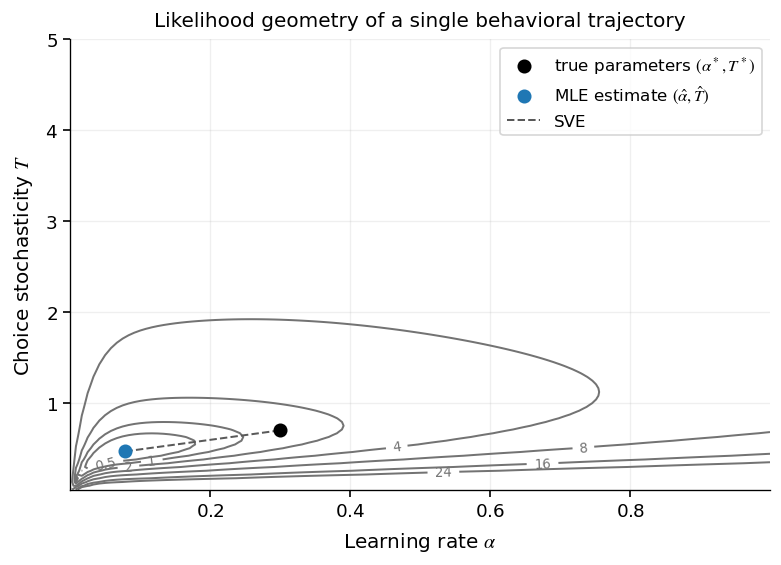

In [12]:
def plot_likelihood_geometry(
    delta_log_likelihood,
    alpha_values,
    temperature_values,
    true_params,
    mle_params,
):
    """
    Plot relative log-likelihood loss contours for one trajectory.

    The visual style follows the publication figure: grayscale contour
    lines, generating parameters as a black point, MLE as a blue point,
    and a dashed line indicating the displacement between them.
    """
    fig, ax = plt.subplots(figsize=(6.4, 4.6))

    contour_levels = [0.5, 1, 2, 4, 8, 16, 24]

    contours = ax.contour(
        alpha_values,
        temperature_values,
        delta_log_likelihood,
        levels=contour_levels,
        colors="0.45",
        linewidths=1.2,
    )

    ax.clabel(
        contours,
        inline=True,
        fontsize=8,
        fmt=lambda x: f"{x:g}",
    )

    # True/generating parameters.
    ax.scatter(
        true_params["alpha"],
        true_params["T"],
        s=55,
        color="black",
        label=r"true parameters $(\alpha^*, T^*)$",
        zorder=5,
    )

    # MLE.
    ax.scatter(
        mle_params["alpha"],
        mle_params["T"],
        s=55,
        color="tab:blue",
        label=r"MLE estimate $(\hat{\alpha}, \hat{T})$",
        zorder=5,
    )

    # Displacement between true parameters and MLE.
    ax.plot(
        [true_params["alpha"], mle_params["alpha"]],
        [true_params["T"], mle_params["T"]],
        linestyle="--",
        linewidth=1.2,
        color="0.35",
        label="SVE",
        zorder=4,
    )

    ax.set_xlabel(r"Learning rate $\alpha$")
    ax.set_ylabel(r"Choice stochasticity $T$")
    ax.set_title("Likelihood geometry of a single behavioral trajectory")

    ax.set_xlim(alpha_values[0], alpha_values[-1])
    ax.set_ylim(temperature_values[0], temperature_values[-1])

    ax.legend(loc="upper right", frameon=True)
    ax.grid(True, alpha=0.20)

    return fig


fig = plot_likelihood_geometry(
    delta_log_likelihood=delta_log_likelihood_grid,
    alpha_values=alpha_grid,
    temperature_values=temperature_grid,
    true_params=TRUE_PARAMS_REPEATED,
    mle_params=mle_params,
)

save_figure(fig, "ll_identifiability_contours_ridge_true_mle.png")
plt.show()

The generating parameters and the MLE do not have to coincide for a single finite stochastic trajectory. More importantly, the shape of the near-optimal region matters: an elongated ridge indicates that different combinations of `alpha` and `T` can explain the same observed sequence similarly well.

### Maximum-likelihood estimation

The likelihood geometry provides an intuitive picture of the optimization problem. In practice, however, the maximum-likelihood estimate is obtained numerically rather than by evaluating the likelihood on a dense parameter grid.

We now apply the MLE procedure to the example trajectory. The comparison below should not be interpreted as a recovery experiment yet. It only shows how one finite stochastic trajectory is mapped to one best-fitting parameter vector.

In [14]:
import pandas as pd

mle_result = fit_mle(single_trajectory)

mle_params = mle_result["params"]
mle_log_likelihood = mle_result["log_likelihood"]

mle_comparison = pd.DataFrame(
    [
        {
            "quantity": "learning rate",
            "symbol": r"$\alpha$",
            "generating value": TRUE_PARAMS_REPEATED["alpha"],
            "MLE estimate": mle_params["alpha"],
        },
        {
            "quantity": "choice stochasticity",
            "symbol": r"$T$",
            "generating value": TRUE_PARAMS_REPEATED["T"],
            "MLE estimate": mle_params["T"],
        },
    ]
)

display(mle_comparison)

print(f"Optimizer success: {mle_result['success']}")
print(f"Optimizer message: {mle_result['message']}")
print(f"Maximum log-likelihood: {mle_log_likelihood:.3f}")

,quantity,symbol,generating value,MLE estimate
0,learning rate,$\alpha$,0.3,0.079855
1,choice stochasticity,$T$,0.7,0.469305


Optimizer success: True
Optimizer message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Maximum log-likelihood: -47.628


For a single finite stochastic trajectory, the MLE does not have to coincide with the generating parameters. This is expected: the observed sequence is only one realization of the data-generating process.

The more important question is not only where the optimum lies, but how strongly the likelihood function localizes that optimum. This brings us back to the likelihood geometry shown above and motivates the next interpretation step: practical identifiability from a single trajectory.

The previous sections introduced three complementary views of parameter identification:

- the log-likelihood quantifies how well a candidate parameter vector explains the observed choices;

- the maximum-likelihood estimate provides the best-fitting parameter vector;

- the likelihood geometry reveals how strongly that optimum is supported by the data.

These perspectives lead naturally to the concept of *practical identifiability*. Even when a unique MLE exists, an elongated high-likelihood ridge indicates that many parameter combinations explain the observed trajectory almost equally well. In such cases, the MLE is numerically well defined but statistically weakly localized.

For this reason, practical identifiability depends not only on the location of the optimum but also on the local geometry of the log-likelihood function.

# Large-scale simulation experiments

## Repeated simulations from fixed generating parameters

The previous sections focused on understanding a single behavioral trajectory.

We now move from individual examples to large-scale simulation experiments. Instead of analyzing one realization, we repeatedly simulate independent behavioral trajectories under the same generating parameters. This allows us to study the statistical properties of maximum-likelihood estimation across repeated experiments rather than for a single stochastic realization.

The first experiment repeatedly simulates datasets generated from fixed model parameters.

Each replication consists of three steps:

1. simulate one behavioral trajectory,
2. estimate its parameters by maximum likelihood,
3. store the results for later statistical analysis.

The function below represents one independent synthetic experiment. It combines simulation and parameter estimation into a single reusable unit.

In [15]:
def run_single_replication(params, n_trials=N_TRIALS, rng=None):
    """
    Run one synthetic experiment:
    1. simulate one trajectory,
    2. fit parameters by MLE,
    3. return a compact result record.
    """
    if rng is None:
        rng = np.random.default_rng()

    trajectory = simulate_choice_outcome_sequence(
        params=params,
        n_trials=n_trials,
        rng=rng,
    )

    mle = fit_mle(trajectory)
    estimated = mle["params"]

    return {
        "true_alpha": params["alpha"],
        "true_T": params["T"],
        "estimated_alpha": estimated["alpha"],
        "estimated_T": estimated["T"],
        "log_likelihood": mle["log_likelihood"],
        "optimizer_success": mle["success"],
        "optimizer_message": str(mle["message"]),
    }

Before running many replications, we inspect the output of a single replication. This checks that simulation, fitting, and result collection are connected correctly.

In [16]:
rng = np.random.default_rng(SEED)

single_replication_result = run_single_replication(
    params=TRUE_PARAMS_REPEATED,
    n_trials=N_TRIALS,
    rng=rng,
)

display(pd.DataFrame([single_replication_result]))

,true_alpha,true_T,estimated_alpha,estimated_T,log_likelihood,optimizer_success,optimizer_message
0,0.3,0.7,0.079855,0.469305,-47.628098,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...


We can now repeat the same synthetic experiment many times. Each replication uses the same generating parameters but produces a different stochastic choice–outcome sequence.

In [17]:
def run_repeated_simulations(config, n_trials=N_TRIALS, seed=SEED):
    """
    Run repeated simulations from fixed generating parameters.
    """
    rng = np.random.default_rng(seed)

    true_params = {
        "alpha": config.true_alpha,
        "T": config.true_temperature,
    }

    records = []

    for _ in range(config.n_replications):
        record = run_single_replication(
            params=true_params,
            n_trials=n_trials,
            rng=rng,
        )
        records.append(record)

    return pd.DataFrame(records)

The cell below runs the repeated-simulation experiment. The resulting table is the starting point for the recovery and boundary-hit diagnostics.

In [18]:
repeated_results = run_repeated_simulations(
    config=REPEATED_SIM,
    n_trials=N_TRIALS,
    seed=SEED,
)

display(repeated_results.head())

print(f"Number of replications: {len(repeated_results)}")
print(f"Successful optimizations: {repeated_results['optimizer_success'].sum()} / {len(repeated_results)}")

,true_alpha,true_T,estimated_alpha,estimated_T,log_likelihood,optimizer_success,optimizer_message
0,0.3,0.7,0.079855,0.469305,-47.628098,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,0.3,0.7,0.402191,0.716948,-52.008215,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
2,0.3,0.7,0.466360,0.696731,-49.342882,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
3,0.3,0.7,0.258409,0.598868,-48.033719,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
4,0.3,0.7,0.999000,1.109268,-51.312507,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


Number of replications: 200
Successful optimizations: 200 / 200


### Recovered estimates and boundary hits

The repeated-simulation table can now be summarized at the level of recovered parameter estimates.

We inspect two aspects:

1. how far the recovered estimates are from the generating parameters,
2. how often the optimizer reaches the boundary of the admissible parameter space.

Boundary hits are diagnostic warnings: they suggest that the optimum may be driven toward an imposed parameter limit rather than being well localized in the interior.

In [19]:
def is_boundary_hit(value, bounds, tolerance=BOUNDARY_TOL):
    """
    Check whether a scalar estimate lies close to either boundary.
    """
    lower, upper = bounds
    return (
        abs(value - lower) <= tolerance
        or abs(value - upper) <= tolerance
    )


def add_recovery_diagnostics(results):
    """
    Add scaled errors and boundary-hit indicators to repeated-simulation results.
    """
    results = results.copy()

    alpha_range = ALPHA_BOUNDS[1] - ALPHA_BOUNDS[0]
    T_range = T_BOUNDS[1] - T_BOUNDS[0]

    results["scaled_alpha_error"] = (
        (results["estimated_alpha"] - results["true_alpha"]) / alpha_range
    )
    results["scaled_T_error"] = (
        (results["estimated_T"] - results["true_T"]) / T_range
    )

    results["SVE"] = np.sqrt(
        results["scaled_alpha_error"] ** 2
        + results["scaled_T_error"] ** 2
    )

    results["alpha_boundary_hit"] = results["estimated_alpha"].apply(
        lambda x: is_boundary_hit(x, ALPHA_BOUNDS)
    )
    results["T_boundary_hit"] = results["estimated_T"].apply(
        lambda x: is_boundary_hit(x, T_BOUNDS)
    )
    results["boundary_hit"] = (
        results["alpha_boundary_hit"] | results["T_boundary_hit"]
    )

    return results


repeated_diagnostics = add_recovery_diagnostics(repeated_results)

summary = {
    "median_SVE": repeated_diagnostics["SVE"].median(),
    "mean_SVE": repeated_diagnostics["SVE"].mean(),
    "boundary_hit_rate": repeated_diagnostics["boundary_hit"].mean(),
    "alpha_boundary_hit_rate": repeated_diagnostics["alpha_boundary_hit"].mean(),
    "T_boundary_hit_rate": repeated_diagnostics["T_boundary_hit"].mean(),
}

pd.DataFrame([summary])

,median_SVE,mean_SVE,boundary_hit_rate,alpha_boundary_hit_rate,T_boundary_hit_rate
0,0.149967,0.238905,0.105,0.105,0.01


The next plot shows the recovered MLE estimates across repeated simulations. The generating parameters are marked as a reference point. A tight cloud around this point would indicate stable recovery; a structured or dispersed cloud indicates that different stochastic trajectories can lead to substantially different estimates.

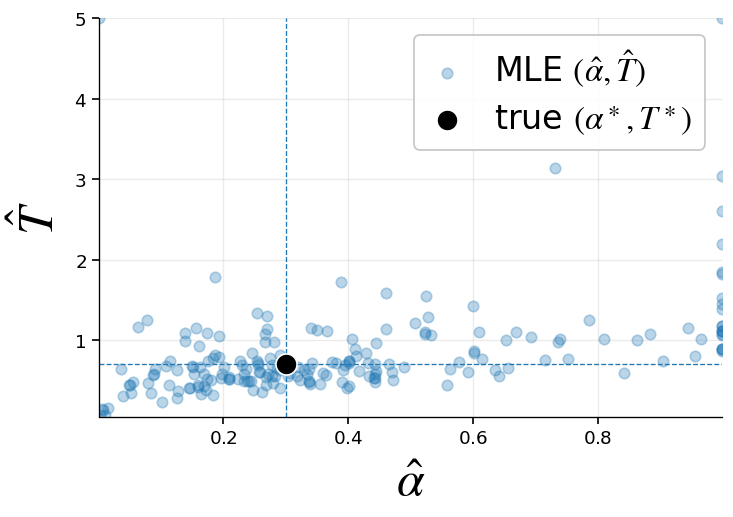

In [20]:
def plot_recovered_estimates_publication_style(results):
    """
    Plot recovered MLE estimates from repeated simulations.

    Visual style intentionally matches the original publication figure.
    """
    fig, ax = plt.subplots()

    # MLE cloud
    mle_handle = ax.scatter(
        results["estimated_alpha"],
        results["estimated_T"],
        marker="o",
        s=40,
        alpha=0.30,
        rasterized=True,
        label=r"MLE $(\hat{\alpha}, \hat{T})$",
    )

    alpha_true = results["true_alpha"].iloc[0]
    T_true = results["true_T"].iloc[0]

    # Generating parameters
    true_handle = ax.scatter(
        [alpha_true],
        [T_true],
        s=160,
        marker="o",
        c="black",
        edgecolors="white",
        linewidths=1.0,
        label=r"true $(\alpha^\ast, T^\ast)$",
        zorder=5,
    )

    # Reference lines through generating parameters
    ax.axvline(alpha_true, linestyle="--", linewidth=0.8)
    ax.axhline(T_true, linestyle="--", linewidth=0.8)

    ax.set_xlabel(r"$\hat{\alpha}$", fontsize=30)
    ax.set_ylabel(r"$\hat{T}$", fontsize=30)

    ax.set_xlim(ALPHA_BOUNDS[0], ALPHA_BOUNDS[1])
    ax.set_ylim(T_BOUNDS[0], T_BOUNDS[1])
    set_nice_ticks(ax, max_ticks=6)

    ax.legend(
        handles=[mle_handle, true_handle],
        loc="upper right",
        frameon=True,
        fancybox=True,
        framealpha=0.90,
        edgecolor="0.75",
        facecolor="white",
        fontsize=20,
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
    )

    return fig


fig = plot_recovered_estimates_publication_style(repeated_diagnostics)
save_figure(fig, "mle_scatter_across_series_left.png")
plt.show()

The same estimates can also be expressed as signed, range-scaled errors. This representation makes the two parameters comparable despite their different numerical ranges and directly shows the components later combined into the scaled vector error.

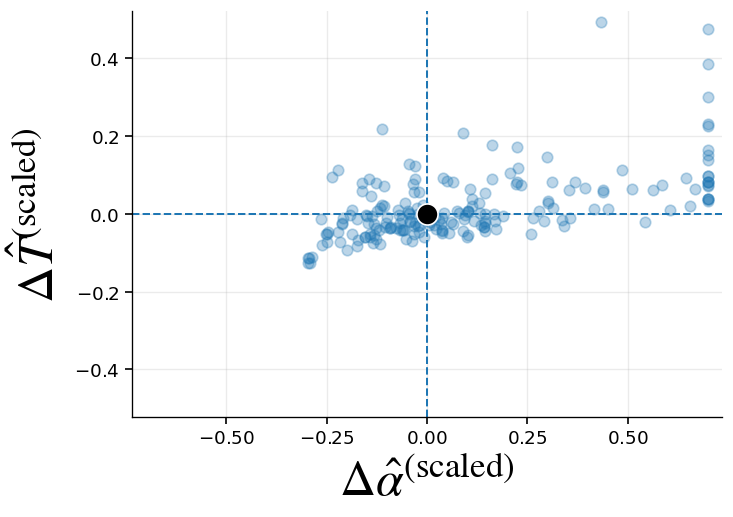

In [21]:
def robust_symmetric_limits(x, q=99.0, pad=0.05):
    """
    Compute robust symmetric axis limits around zero.
    """
    m = float(np.percentile(np.abs(x), q))
    m *= (1.0 + pad)
    return (-m, m)


def plot_signed_scaled_errors_publication_style(
    results,
    x_lim=None,
    y_lim=None,
    robust_q=99.0,
    robust_pad=0.05,
):
    """
    Plot signed, range-scaled estimation errors.

    Visual style intentionally matches the original publication figure.
    """
    dalpha_scaled = results["scaled_alpha_error"].to_numpy()
    dT_scaled = results["scaled_T_error"].to_numpy()

    if x_lim is None:
        x_lim = robust_symmetric_limits(
            dalpha_scaled,
            q=robust_q,
            pad=robust_pad,
        )

    if y_lim is None:
        y_lim = robust_symmetric_limits(
            dT_scaled,
            q=robust_q,
            pad=robust_pad,
        )

    fig, ax = plt.subplots()

    # Error cloud
    mle_error_handle = ax.scatter(
        dalpha_scaled,
        dT_scaled,
        marker="o",
        s=40,
        alpha=0.30,
        rasterized=True,
        label=r"MLE error",
    )

    # Zero reference lines
    ax.axvline(0.0, linestyle="--", linewidth=1.2)
    ax.axhline(0.0, linestyle="--", linewidth=1.2)

    # Zero-error point
    zero_handle = ax.scatter(
        [0.0],
        [0.0],
        s=160,
        marker="o",
        c="black",
        edgecolors="white",
        linewidths=1.0,
        label=r"zero error",
        zorder=5,
    )

    ax.set_xlabel(r"$\Delta\hat{\alpha}^{(\mathrm{scaled})}$", fontsize=30)
    ax.set_ylabel(r"$\Delta\hat{T}^{(\mathrm{scaled})}$", fontsize=30)

    ax.set_xlim(float(x_lim[0]), float(x_lim[1]))
    ax.set_ylim(float(y_lim[0]), float(y_lim[1]))
    set_nice_ticks(ax, max_ticks=6)

    # No legend, matching the original publication-style cell.
    # ax.legend(
    #     handles=[mle_error_handle, zero_handle],
    #     loc="upper right",
    #     frameon=False,
    #     fontsize=18,
    # )

    return fig


fig = plot_signed_scaled_errors_publication_style(repeated_diagnostics)
save_figure(fig, "signed_scaled_errors_scatter_right.png")
plt.show()

 These diagnostics show whether the estimation procedure produces a compact distribution of estimates around the generating parameters, or whether recovery errors remain structured even when the model is correctly specified.

### Scaled vector error distribution

The previous plots show component-wise recovery errors. We now summarize both parameter errors with a single distance measure: the scaled vector error (SVE).

SVE is computed as the Euclidean distance between generating and recovered parameters after scaling each parameter by its admissible range. This makes errors in `alpha` and `T` comparable despite their different numerical scales.

The histogram below shows the distribution of SVE across repeated simulations.

Standardized (range-scaled) parameter error:
  median = 0.1500
  IQR    = [0.0830, 0.3037]
  p90    = 0.7012
  P(bound hit) = 0.105  (tol = 0.001)


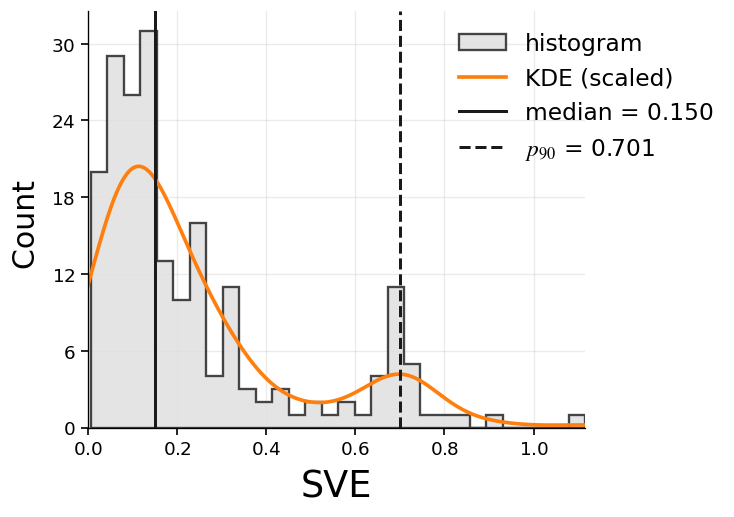

In [22]:
from scipy.stats import gaussian_kde


def plot_sve_distribution_publication_style(
    results,
    n_bins=30,
    x_max=None,
    use_log_y=False,
    kde_grid_n=400,
    kde_bw="scott",
):
    """
    Plot the SVE distribution across repeated simulations.

    Visual style intentionally matches the original publication figure.
    """
    err_scaled = results["SVE"].to_numpy(dtype=float)

    # Robust summaries
    p25, p50, p75 = np.percentile(err_scaled, [25, 50, 75])
    p90 = np.percentile(err_scaled, 90)

    p_any_bound = float(results["boundary_hit"].mean())

    print("Standardized (range-scaled) parameter error:")
    print(f"  median = {p50:.4f}")
    print(f"  IQR    = [{p25:.4f}, {p75:.4f}]")
    print(f"  p90    = {p90:.4f}")
    print(f"  P(bound hit) = {p_any_bound:.3f}  (tol = {BOUNDARY_TOL})")

    xlim_max = float(np.max(err_scaled)) if x_max is None else float(x_max)

    fig, ax = plt.subplots()

    # Histogram
    ax.hist(
        err_scaled,
        bins=n_bins,
        histtype="stepfilled",
        facecolor="0.88",
        edgecolor="0.15",
        linewidth=1.4,
        alpha=0.85,
        label="histogram",
        zorder=1,
    )

    # KDE overlay, scaled to histogram counts
    x_grid = np.linspace(0.0, xlim_max, kde_grid_n)
    kde = gaussian_kde(err_scaled, bw_method=kde_bw)
    density = kde(x_grid)

    bin_width = xlim_max / n_bins if n_bins > 0 else 1.0
    density_as_counts = density * err_scaled.size * bin_width

    ax.plot(
        x_grid,
        density_as_counts,
        linewidth=2.2,
        label="KDE (scaled)",
        zorder=2,
    )

    # Reference lines
    ax.axvline(
        p50,
        linestyle="-",
        linewidth=1.8,
        color="0.10",
        label=rf"median = {p50:.3f}",
        zorder=3,
    )
    ax.axvline(
        p90,
        linestyle="--",
        linewidth=1.8,
        color="0.10",
        label=rf"$p_{{90}}$ = {p90:.3f}",
        zorder=3,
    )

    ax.set_xlabel("SVE", fontsize=22)
    ax.set_ylabel(r"Count ", fontsize=18)
    ax.set_xlim(0.0, xlim_max)

    if use_log_y:
        ax.set_yscale("log")

    set_nice_ticks(ax, max_ticks=6)

    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.3, 1.0),
        fontsize=14,
        frameon=False,
    )

    return fig


fig = plot_sve_distribution_publication_style(repeated_diagnostics)
save_figure(fig, "standardized_error_hist_kde.png")
plt.show()

A distribution concentrated near zero would indicate stable parameter recovery. A heavy right tail indicates that some stochastic trajectories lead to large recovery errors, even though the data were generated by the same model and the same generating parameters.

### Effect of trajectory length on parameter recovery

The previous diagnostics used a fixed trajectory length. We now ask whether longer behavioral sequences improve parameter recovery.

For each value of `n_trials`, we repeatedly simulate trajectories from the same generating parameters, fit the model by MLE, and summarize recovery quality using boundary-hit rates, SVE, and recovered-parameter uncertainty.

In [23]:
@dataclass(frozen=True)
class TrajectoryLengthExperiment:
    """
    Configuration for the trajectory-length recovery experiment.
    """
    n_trials_list: tuple[int, ...] = (40, 80, 160, 320)
    n_series: int = 200
    true_alpha: float = 0.30
    true_temperature: float = 0.70
    alpha_init_sd_frac: float = 0.15
    temperature_init_sd_frac: float = 0.15


TRAJ_LENGTH_EXP = TrajectoryLengthExperiment()


def random_initial_theta(bounds, rng, alpha_sd_frac=0.15, temperature_sd_frac=0.15):
    """
    Draw a random optimizer start near the center of the parameter bounds.
    """
    alpha_bounds, T_bounds = bounds

    alpha_range = alpha_bounds[1] - alpha_bounds[0]
    T_range = T_bounds[1] - T_bounds[0]

    alpha_center = 0.5 * (alpha_bounds[0] + alpha_bounds[1])
    T_center = 0.5 * (T_bounds[0] + T_bounds[1])

    theta = np.array(
        [
            alpha_center + rng.normal(0.0, alpha_sd_frac * alpha_range),
            T_center + rng.normal(0.0, temperature_sd_frac * T_range),
        ],
        dtype=float,
    )

    theta[0] = np.clip(theta[0], alpha_bounds[0], alpha_bounds[1])
    theta[1] = np.clip(theta[1], T_bounds[0], T_bounds[1])

    return theta


def run_trajectory_length_experiment(config, seed=SEED):
    """
    Run MLE recovery for several trajectory lengths.

    Returns
    -------
    summary : pandas.DataFrame
        One row per trajectory length.
    raw_results : pandas.DataFrame
        One row per simulated series.
    """
    rng = np.random.default_rng(seed)

    bounds = [ALPHA_BOUNDS, T_BOUNDS]

    true_params = {
        "alpha": config.true_alpha,
        "T": config.true_temperature,
    }

    alpha_range = ALPHA_BOUNDS[1] - ALPHA_BOUNDS[0]
    T_range = T_BOUNDS[1] - T_BOUNDS[0]

    raw_records = []
    summary_records = []

    for n_trials in config.n_trials_list:
        for series_id in range(config.n_series):
            trajectory = simulate_choice_outcome_sequence(
                params=true_params,
                n_trials=int(n_trials),
                rng=rng,
            )

            x0 = random_initial_theta(
                bounds=bounds,
                rng=rng,
                alpha_sd_frac=config.alpha_init_sd_frac,
                temperature_sd_frac=config.temperature_init_sd_frac,
            )

            mle = fit_mle(
                trajectory,
                initial_theta=x0,
            )

            estimated = mle["params"]

            raw_records.append(
                {
                    "n_trials": int(n_trials),
                    "series_id": int(series_id),
                    "true_alpha": true_params["alpha"],
                    "true_T": true_params["T"],
                    "estimated_alpha": estimated["alpha"],
                    "estimated_T": estimated["T"],
                    "log_likelihood": mle["log_likelihood"],
                    "optimizer_success": mle["success"],
                    "optimizer_message": str(mle["message"]),
                }
            )

    raw_results = pd.DataFrame(raw_records)
    raw_results = add_recovery_diagnostics(raw_results)

    for n_trials, group in raw_results.groupby("n_trials", sort=True):
        ok = group["optimizer_success"] & np.isfinite(group["estimated_alpha"]) & np.isfinite(group["estimated_T"])
        ok_group = group.loc[ok]

        if len(ok_group) > 0:
            scaled_alpha_error = ok_group["scaled_alpha_error"].to_numpy()
            scaled_T_error = ok_group["scaled_T_error"].to_numpy()
            sve = ok_group["SVE"].to_numpy()

            r_tradeoff = (
                float(np.corrcoef(scaled_alpha_error, scaled_T_error)[0, 1])
                if len(ok_group) > 3
                else np.nan
            )

            summary_records.append(
                {
                    "n_trials": int(n_trials),
                    "success_rate": float(ok.mean()),
                    "p_bound_hit_ok": float(ok_group["boundary_hit"].mean()),
                    "med_alpha_hat": float(ok_group["estimated_alpha"].median()),
                    "mean_alpha_hat": float(ok_group["estimated_alpha"].mean()),
                    "med_T_hat": float(ok_group["estimated_T"].median()),
                    "mean_T_hat": float(ok_group["estimated_T"].mean()),
                    "med_err": float(np.median(sve)),
                    "mean_err": float(np.mean(sve)),
                    "p90_err": float(np.percentile(sve, 90)),
                    "r_tradeoff": r_tradeoff,
                }
            )
        else:
            summary_records.append(
                {
                    "n_trials": int(n_trials),
                    "success_rate": float(ok.mean()),
                    "p_bound_hit_ok": np.nan,
                    "med_alpha_hat": np.nan,
                    "mean_alpha_hat": np.nan,
                    "med_T_hat": np.nan,
                    "mean_T_hat": np.nan,
                    "med_err": np.nan,
                    "mean_err": np.nan,
                    "p90_err": np.nan,
                    "r_tradeoff": np.nan,
                }
            )

    summary = pd.DataFrame(summary_records)

    return summary, raw_results

The cell below runs the trajectory-length experiment and prints the same recovery summaries used for interpretation: success rate, boundary-hit rate, recovered-parameter summaries, SVE summaries, and the trade-off correlation between scaled component errors.

In [24]:
trajectory_length_summary, trajectory_length_raw = run_trajectory_length_experiment(
    TRAJ_LENGTH_EXP,
    seed=SEED,
)

print("Effect of trajectory length on MLE recovery (fixed true parameters)")
print(
    f"True params: alpha = {TRAJ_LENGTH_EXP.true_alpha:.3f}, "
    f"T = {TRAJ_LENGTH_EXP.true_temperature:.3f}"
)
print(f"Series per n_trials: {TRAJ_LENGTH_EXP.n_series}")
print()

display(trajectory_length_summary)

Effect of trajectory length on MLE recovery (fixed true parameters)
True params: alpha = 0.300, T = 0.700
Series per n_trials: 200



,n_trials,success_rate,p_bound_hit_ok,med_alpha_hat,mean_alpha_hat,med_T_hat,mean_T_hat,med_err,mean_err,p90_err,r_tradeoff
0,40,1.0,0.240,0.348761,0.421175,0.663983,0.982197,0.233267,0.326776,0.716267,0.103400
1,80,1.0,0.115,0.308303,0.362171,0.665371,0.837632,0.151120,0.230306,0.702045,0.190742
2,160,1.0,0.030,0.311269,0.339162,0.715203,0.765841,0.114785,0.160130,0.319893,0.648755
3,320,1.0,0.015,0.299688,0.322304,0.686954,0.713279,0.083411,0.126352,0.269741,0.645492


The plot below summarizes recovered-parameter uncertainty as a function of trajectory length. The line shows the median recovered estimate, while the shaded band shows the interquartile range. Dashed horizontal lines mark the generating parameter values.

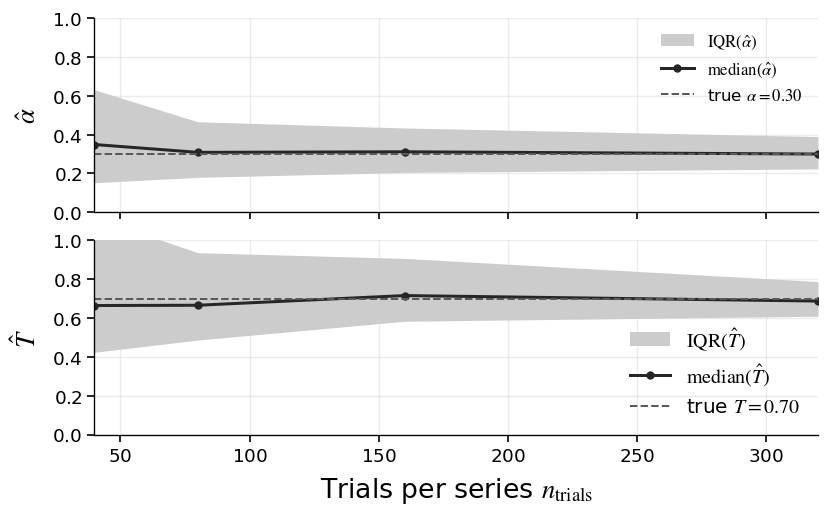

In [25]:
def plot_recovery_vs_trials_publication_style(
    raw_results,
    output_path="recovery_vs_trials_median_iqr_grayscale.png",
    figsize=(6.8, 4.2),
    alpha_ylim=(0.0, 1.0),
    T_ylim=(0.0, 1.0),
):
    """
    Plot recovery uncertainty versus trajectory length.

    Visual style intentionally matches the original publication figure.
    """
    n_trials_list = sorted(raw_results["n_trials"].unique())

    alpha_q25 = np.full(len(n_trials_list), np.nan, dtype=float)
    alpha_q50 = np.full(len(n_trials_list), np.nan, dtype=float)
    alpha_q75 = np.full(len(n_trials_list), np.nan, dtype=float)

    T_q25 = np.full(len(n_trials_list), np.nan, dtype=float)
    T_q50 = np.full(len(n_trials_list), np.nan, dtype=float)
    T_q75 = np.full(len(n_trials_list), np.nan, dtype=float)

    for k, n_trials in enumerate(n_trials_list):
        group = raw_results[raw_results["n_trials"] == n_trials]
        mask_ok = (
            group["optimizer_success"]
            & np.isfinite(group["estimated_alpha"])
            & np.isfinite(group["estimated_T"])
        )

        ok_group = group.loc[mask_ok]

        if len(ok_group) > 0:
            alpha_q25[k], alpha_q50[k], alpha_q75[k] = np.percentile(
                ok_group["estimated_alpha"],
                [25, 50, 75],
            )
            T_q25[k], T_q50[k], T_q75[k] = np.percentile(
                ok_group["estimated_T"],
                [25, 50, 75],
            )

    alpha_true = float(raw_results["true_alpha"].iloc[0])
    T_true = float(raw_results["true_T"].iloc[0])

    fig, (ax0, ax1) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        layout="constrained",
    )

    # Grayscale palette, unchanged from the original cell.
    line_dark = "0.15"
    line_mid = "0.35"
    band_light = "0.80"

    # Alpha panel.
    ax0.fill_between(
        n_trials_list,
        alpha_q25,
        alpha_q75,
        color=band_light,
        linewidth=0.0,
        label=r"$\mathrm{IQR}(\hat{\alpha})$",
    )
    ax0.plot(
        n_trials_list,
        alpha_q50,
        marker="o",
        linewidth=1.8,
        color=line_dark,
        label=r"$\mathrm{median}(\hat{\alpha})$",
    )
    ax0.axhline(
        alpha_true,
        linestyle="--",
        linewidth=1.2,
        color=line_mid,
        label=rf"true $\alpha={alpha_true:.2f}$",
    )

    ax0.set_ylabel(r"$\hat{\alpha}$", fontsize=16)
    ax0.set_xlim(min(n_trials_list), max(n_trials_list))
    ax0.set_ylim(*alpha_ylim)
    set_nice_ticks(ax0, max_ticks=6)
    ax0.legend(loc="upper right", frameon=False)

    # T panel.
    ax1.fill_between(
        n_trials_list,
        T_q25,
        T_q75,
        color=band_light,
        linewidth=0.0,
        label=r"$\mathrm{IQR}(\hat{T})$",
    )
    ax1.plot(
        n_trials_list,
        T_q50,
        marker="o",
        linewidth=1.8,
        color=line_dark,
        label=r"$\mathrm{median}(\hat{T})$",
    )
    ax1.axhline(
        T_true,
        linestyle="--",
        linewidth=1.2,
        color=line_mid,
        label=rf"true $T={T_true:.2f}$",
    )

    ax1.set_xlabel(r"Trials per series $n_{\mathrm{trials}}$", fontsize=16)
    ax1.set_ylabel(r"$\hat{T}$", fontsize=16)
    ax1.set_xlim(min(n_trials_list), max(n_trials_list))
    ax1.set_ylim(*T_ylim)
    set_nice_ticks(ax1, max_ticks=6)
    ax1.legend(loc="lower right", frameon=False, fontsize=12)

    return fig


fig = plot_recovery_vs_trials_publication_style(trajectory_length_raw)
save_figure(fig, "recovery_vs_trials_median_iqr_grayscale.png")
plt.show()

Longer trajectories are expected to provide more information about the subject-level parameters. This diagnostic checks whether such additional information reduces recovery uncertainty in practice, and whether the recovered estimates become more concentrated around the generating values.

### Classical parameter recovery from random draws

Before introducing the grid-based and overlap diagnostics, we first perform a standard parameter-recovery analysis commonly used in the literature.

We randomly draw generating parameters from a predefined region, simulate one behavioral trajectory for each draw, fit the model by MLE, and compare generating parameters with recovered estimates.

This section is split into two parts:

- **HEAVY**: simulate datasets, fit MLE, and save raw artifacts,
- **LIGHT**: load saved artifacts and create the recovery figure.

In [26]:
import json
from datetime import datetime, timezone


@dataclass(frozen=True)
class RandomDrawRecoveryExperiment:
    """
    Configuration for classical parameter recovery from random draws.
    """
    n_datasets: int = 10_000
    n_trials: int = 80
    alpha_true_range: tuple[float, float] = (0.05, 0.95)
    temperature_true_range: tuple[float, float] = (0.10, 2.50)
    alpha_init_sd_frac: float = 0.15
    temperature_init_sd_frac: float = 0.15
    output_prefix: str = "random_recovery_N80_M10000"


RANDOM_RECOVERY_EXP = RandomDrawRecoveryExperiment()


def run_random_draw_recovery_experiment(config, seed=SEED):
    """
    Run classical parameter recovery from random draws.

    The function simulates one trajectory for each randomly drawn
    generating parameter vector and fits the model by MLE.
    """
    rng = np.random.default_rng(seed)

    alpha_true = rng.uniform(
        config.alpha_true_range[0],
        config.alpha_true_range[1],
        size=config.n_datasets,
    )
    T_true = rng.uniform(
        config.temperature_true_range[0],
        config.temperature_true_range[1],
        size=config.n_datasets,
    )

    alpha_hat = np.full(config.n_datasets, np.nan, dtype=float)
    T_hat = np.full(config.n_datasets, np.nan, dtype=float)
    success = np.zeros(config.n_datasets, dtype=bool)

    bounds = [ALPHA_BOUNDS, T_BOUNDS]

    for i in range(config.n_datasets):
        params_true = {
            "alpha": float(alpha_true[i]),
            "T": float(T_true[i]),
        }

        trajectory = simulate_choice_outcome_sequence(
            params=params_true,
            n_trials=config.n_trials,
            rng=rng,
        )

        x0 = random_initial_theta(
            bounds=bounds,
            rng=rng,
            alpha_sd_frac=config.alpha_init_sd_frac,
            temperature_sd_frac=config.temperature_init_sd_frac,
        )

        mle = fit_mle(
            trajectory,
            initial_theta=x0,
        )

        alpha_hat[i] = mle["params"]["alpha"]
        T_hat[i] = mle["params"]["T"]
        success[i] = mle["success"]

    alpha_on_bound = np.array(
        [is_boundary_hit(x, ALPHA_BOUNDS) for x in alpha_hat],
        dtype=bool,
    )
    T_on_bound = np.array(
        [is_boundary_hit(x, T_BOUNDS) for x in T_hat],
        dtype=bool,
    )

    return {
        "n_trials": int(config.n_trials),
        "alpha_true": alpha_true,
        "T_true": T_true,
        "alpha_hat": alpha_hat,
        "T_hat": T_hat,
        "success": success,
        "alpha_on_bound": alpha_on_bound,
        "T_on_bound": T_on_bound,
    }


def save_random_draw_recovery_artifacts(results, config):
    """
    Save raw random-draw recovery results and metadata.
    """

    raw_path = RAW_DIR / f"{config.output_prefix}_raw.npz"
    meta_path = METADATA_DIR / f"{config.output_prefix}_metadata.json"

    np.savez_compressed(
        raw_path,
        n_trials=results["n_trials"],
        alpha_true=results["alpha_true"],
        T_true=results["T_true"],
        alpha_hat=results["alpha_hat"],
        T_hat=results["T_hat"],
        success=results["success"],
        alpha_on_bound=results["alpha_on_bound"],
        T_on_bound=results["T_on_bound"],
    )

    metadata = {
        "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "seed": int(SEED),
        "design": {
            "n_datasets": int(config.n_datasets),
            "n_trials": int(config.n_trials),
            "p_reward_A": float(P_REWARD_A),
            "p_reward_B": float(P_REWARD_B),
        },
        "true_sampling": {
            "alpha_true_range": list(map(float, config.alpha_true_range)),
            "T_true_range": list(map(float, config.temperature_true_range)),
        },
        "mle": {
            "alpha_bounds": list(map(float, ALPHA_BOUNDS)),
            "T_bounds": list(map(float, T_BOUNDS)),
            "init_sd_frac_alpha": float(config.alpha_init_sd_frac),
            "init_sd_frac_T": float(config.temperature_init_sd_frac),
            "bound_tol": float(BOUNDARY_TOL),
            "optimizer": CONFIG.identification.optimizer,
        },
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    return raw_path, meta_path


random_recovery_results = run_random_draw_recovery_experiment(
    RANDOM_RECOVERY_EXP,
    seed=SEED,
)

mask_ok = (
    random_recovery_results["success"]
    & np.isfinite(random_recovery_results["alpha_hat"])
    & np.isfinite(random_recovery_results["T_hat"])
)

any_bound = (
    random_recovery_results["alpha_on_bound"]
    | random_recovery_results["T_on_bound"]
)

print("Parameter recovery dataset from random draws:")
print(f"  n_datasets = {RANDOM_RECOVERY_EXP.n_datasets}")
print(f"  n_trials   = {RANDOM_RECOVERY_EXP.n_trials}")
print(f"  success rate = {mask_ok.mean():.3f}")
print(
    "  P(any bound hit | ok) = "
    f"{(any_bound[mask_ok].mean() if mask_ok.any() else np.nan):.3f}"
)

raw_path, meta_path = save_random_draw_recovery_artifacts(
    random_recovery_results,
    RANDOM_RECOVERY_EXP,
)

print("Saved raw data:", raw_path)
print("Saved metadata:", meta_path)

Parameter recovery dataset from random draws:
  n_datasets = 10000
  n_trials   = 80
  success rate = 1.000
  P(any bound hit | ok) = 0.275
Saved raw data: artifacts\raw\random_recovery_N80_M10000_raw.npz
Saved metadata: artifacts\metadata\random_recovery_N80_M10000_metadata.json


The heavy computation above saves raw recovery outputs. The next cell is lightweight: it loads the saved artifact and produces the classical simulated-versus-recovered parameter-recovery figure.

Parameter recovery from random draws:
  r(alpha*, alpha_hat) = 0.419
  r(T*, T_hat)         = 0.517
n=9998, n_trials=80
P(bound hit | ok)=0.28


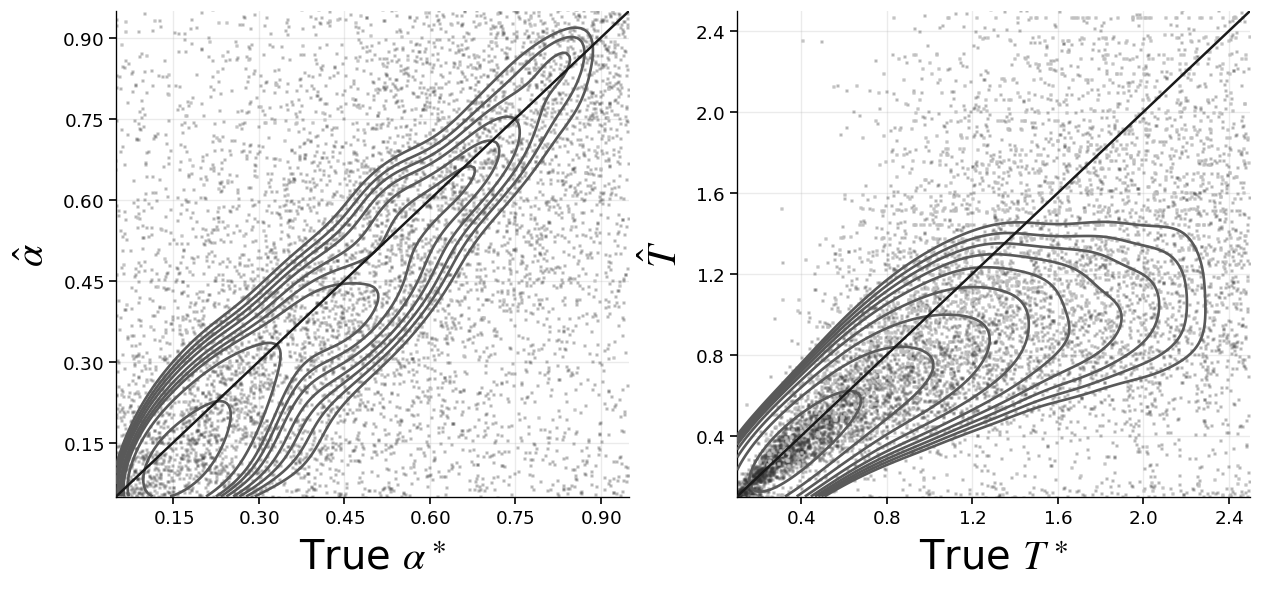

In [27]:
from scipy.stats import pearsonr, gaussian_kde


def load_random_draw_recovery_artifact(config):
    """
    Load saved random-draw recovery results.
    """
    raw_path = RAW_DIR / f"{config.output_prefix}_raw.npz"
    data = np.load(raw_path)

    return {
        "n_trials": int(data["n_trials"]),
        "alpha_true": data["alpha_true"],
        "T_true": data["T_true"],
        "alpha_hat": data["alpha_hat"],
        "T_hat": data["T_hat"],
        "success": data["success"].astype(bool),
        "alpha_on_bound": data["alpha_on_bound"].astype(bool),
        "T_on_bound": data["T_on_bound"].astype(bool),
    }


def plot_random_draw_recovery_publication_style(
    results,
    fig_path="recovery_scatter_kde_nomarginals.png",
):
    """
    Plot classical parameter recovery from random draws.

    Visual style intentionally matches the original publication figure.
    """
    alpha_true = results["alpha_true"]
    T_true = results["T_true"]
    alpha_hat = results["alpha_hat"]
    T_hat = results["T_hat"]
    success = results["success"]
    alpha_on_bound = results["alpha_on_bound"]
    T_on_bound = results["T_on_bound"]

    mask_ok = success & np.isfinite(alpha_hat) & np.isfinite(T_hat)
    any_bound = alpha_on_bound | T_on_bound
    mask_ok_nb = mask_ok & (~any_bound)
    mask_ok_bh = mask_ok & any_bound

    r_alpha, _ = pearsonr(alpha_true[mask_ok], alpha_hat[mask_ok])
    r_T, _ = pearsonr(T_true[mask_ok], T_hat[mask_ok])

    print("Parameter recovery from random draws:")
    print(f"  r(alpha*, alpha_hat) = {r_alpha:.3f}")
    print(f"  r(T*, T_hat)         = {r_T:.3f}")

    figsize = (10.4, 4.8)

    point_alpha = 0.20
    scatter_color_ok = "0.20"

    highlight_boundary = True
    scatter_color_bh = "0.75"

    identity_color = "0.10"
    identity_lw = 1.5

    kde_levels = 9
    kde_linewidths = 1.6
    kde_color = "0.35"
    kde_grid_n = 140
    kde_min_n = 200

    alpha_xlim = (0.05, 0.95)
    alpha_ylim = (0.05, 0.95)
    T_xlim = (0.10, 2.50)
    T_ylim = (0.10, 2.50)

    def kde_contours(ax, x, y, xlim, ylim, levels=9):
        if x.size < kde_min_n:
            return

        xs = np.linspace(xlim[0], xlim[1], kde_grid_n)
        ys = np.linspace(ylim[0], ylim[1], kde_grid_n)
        X, Y = np.meshgrid(xs, ys)

        kde = gaussian_kde(np.vstack([x, y]))
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        qs = np.linspace(0.70, 0.98, levels)
        lvls = np.quantile(Z, qs)
        lvls = np.unique(lvls)

        if lvls.size >= 2:
            ax.contour(
                X,
                Y,
                Z,
                levels=lvls,
                colors=kde_color,
                linewidths=kde_linewidths,
                zorder=3,
            )

    def panel(ax, x_true, y_hat, x_nb, y_nb, xlim, ylim, xlabel, ylabel, fontsize=24):
        ax.scatter(
            x_nb,
            y_nb,
            marker=",",
            s=1,
            alpha=point_alpha,
            c=scatter_color_ok,
            rasterized=True,
            zorder=1,
        )

        if highlight_boundary and mask_ok_bh.any():
            ax.scatter(
                x_true[mask_ok_bh],
                y_hat[mask_ok_bh],
                marker=",",
                s=1,
                alpha=0.70,
                c=scatter_color_bh,
                rasterized=True,
                zorder=2,
            )

        kde_contours(
            ax,
            x_nb,
            y_nb,
            xlim=xlim,
            ylim=ylim,
            levels=kde_levels,
        )

        ax.plot(
            [xlim[0], xlim[1]],
            [xlim[0], xlim[1]],
            color=identity_color,
            linewidth=identity_lw,
            zorder=4,
        )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(xlabel, fontsize=fontsize)
        ax.set_ylabel(ylabel, fontsize=fontsize)
        set_nice_ticks(ax, max_ticks=6)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    panel(
        ax=axes[0],
        x_true=alpha_true,
        y_hat=alpha_hat,
        x_nb=alpha_true[mask_ok_nb],
        y_nb=alpha_hat[mask_ok_nb],
        xlim=alpha_xlim,
        ylim=alpha_ylim,
        xlabel=r"True $\alpha^\ast$",
        ylabel=r"$\hat{\alpha}$",
        fontsize=24,
    )

    panel(
        ax=axes[1],
        x_true=T_true,
        y_hat=T_hat,
        x_nb=T_true[mask_ok_nb],
        y_nb=T_hat[mask_ok_nb],
        xlim=T_xlim,
        ylim=T_ylim,
        xlabel=r"True $T^\ast$",
        ylabel=r"$\hat{T}$",
        fontsize=24,
    )

    p_bound_ok = float(any_bound[mask_ok].mean()) if mask_ok.any() else np.nan

    print(f"n={int(mask_ok.sum())}, n_trials={results['n_trials']}")
    print(f"P(bound hit | ok)={p_bound_ok:.2f}")

    return fig


random_recovery_loaded = load_random_draw_recovery_artifact(RANDOM_RECOVERY_EXP)

fig = plot_random_draw_recovery_publication_style(random_recovery_loaded)
save_figure(fig, "recovery_scatter_kde_nomarginals.png")
plt.show()

This classical parameter-recovery plot compares generating and recovered parameters across random draws from the parameter space. Deviations from the identity line, broad scatter, and density contours away from the diagonal indicate limited recovery quality in parts of the parameter space.

This provides the standard recovery baseline before moving to the more diagnostic analyses introduced in the next sections.

### Grid-based parameter recovery diagnostics

Classical parameter recovery samples generating parameters randomly. Here we use a more diagnostic approach: we evaluate recovery quality on a structured grid over the generating-parameter space.

For each grid point $(\alpha^\ast, T^\ast)$, we simulate multiple independent trajectories, fit the model by MLE, and summarize:

- median scaled vector error,
- boundary-hit rate conditional on successful fits.

This is a computationally expensive section. The heavy cell saves raw artifacts, and the lightweight plotting cell loads them later.

In [28]:
import json
from datetime import datetime, timezone
from dataclasses import dataclass, field

@dataclass(frozen=True)
class GridRecoveryExperiment:
    """
    Configuration for grid-based parameter recovery.
    """
    alpha_grid: np.ndarray = field(
        default_factory=lambda: np.linspace(0.05, 0.95, 31)
    )
    temperature_grid: np.ndarray = field(
        default_factory=lambda: np.linspace(0.10, 2.50, 31)
    )
    n_trials_per_series: int = 80
    n_replications: int = 80
    alpha_init_sd_frac: float = 0.15
    temperature_init_sd_frac: float = 0.15
    output_prefix: str = "grid_recovery_N80_A31_T31_R80"


GRID_RECOVERY_EXP = GridRecoveryExperiment()


def run_grid_recovery_experiment(config, seed=SEED):
    """
    Run grid-based parameter recovery.

    This is a heavy computation: for each generating parameter pair,
    multiple trajectories are simulated and fitted by MLE.
    """
    rng = np.random.default_rng(seed)

    alpha_grid = np.asarray(config.alpha_grid, dtype=float)
    T_grid = np.asarray(config.temperature_grid, dtype=float)

    nA = alpha_grid.size
    nT = T_grid.size
    R = int(config.n_replications)

    alpha_hats_all = np.full((nT, nA, R), np.nan, dtype=float)
    T_hats_all = np.full((nT, nA, R), np.nan, dtype=float)
    success_all = np.zeros((nT, nA, R), dtype=bool)

    median_err_scaled = np.full((nT, nA), np.nan, dtype=float)
    p_bound_hit_ok = np.full((nT, nA), np.nan, dtype=float)
    success_rate = np.full((nT, nA), np.nan, dtype=float)
    median_alpha_hat = np.full((nT, nA), np.nan, dtype=float)
    median_T_hat = np.full((nT, nA), np.nan, dtype=float)

    bounds = [ALPHA_BOUNDS, T_BOUNDS]

    alpha_range = ALPHA_BOUNDS[1] - ALPHA_BOUNDS[0]
    T_range = T_BOUNDS[1] - T_BOUNDS[0]

    for iT, T_true in enumerate(T_grid):
        for jA, alpha_true in enumerate(alpha_grid):
            params_true = {
                "alpha": float(alpha_true),
                "T": float(T_true),
            }

            for r in range(R):
                trajectory = simulate_choice_outcome_sequence(
                    params=params_true,
                    n_trials=config.n_trials_per_series,
                    rng=rng,
                )

                x0 = random_initial_theta(
                    bounds=bounds,
                    rng=rng,
                    alpha_sd_frac=config.alpha_init_sd_frac,
                    temperature_sd_frac=config.temperature_init_sd_frac,
                )

                mle = fit_mle(
                    trajectory,
                    initial_theta=x0,
                )

                alpha_hats_all[iT, jA, r] = mle["params"]["alpha"]
                T_hats_all[iT, jA, r] = mle["params"]["T"]
                success_all[iT, jA, r] = mle["success"]

            a_hats = alpha_hats_all[iT, jA, :]
            t_hats = T_hats_all[iT, jA, :]
            ok = success_all[iT, jA, :]

            mask_ok = ok & np.isfinite(a_hats) & np.isfinite(t_hats)

            success_rate[iT, jA] = float(mask_ok.mean())

            if mask_ok.any():
                a_ok = a_hats[mask_ok]
                t_ok = t_hats[mask_ok]

                a_on_bound = np.array(
                    [is_boundary_hit(x, ALPHA_BOUNDS) for x in a_ok],
                    dtype=bool,
                )
                t_on_bound = np.array(
                    [is_boundary_hit(x, T_BOUNDS) for x in t_ok],
                    dtype=bool,
                )
                any_on_bound = a_on_bound | t_on_bound

                p_bound_hit_ok[iT, jA] = float(any_on_bound.mean())

                median_alpha_hat[iT, jA] = float(np.median(a_ok))
                median_T_hat[iT, jA] = float(np.median(t_ok))

                da = (a_ok - alpha_true) / alpha_range
                dT = (t_ok - T_true) / T_range
                err_scaled = np.sqrt(da**2 + dT**2)

                median_err_scaled[iT, jA] = float(np.median(err_scaled))

    return {
        "alpha_grid": alpha_grid,
        "T_grid": T_grid,
        "alpha_hats_all": alpha_hats_all,
        "T_hats_all": T_hats_all,
        "success_all": success_all,
        "median_err_scaled": median_err_scaled,
        "p_bound_hit_ok": p_bound_hit_ok,
        "success_rate": success_rate,
        "median_alpha_hat": median_alpha_hat,
        "median_T_hat": median_T_hat,
    }


def save_grid_recovery_artifacts(results, config):
    """
    Save grid-recovery raw arrays and metadata.
    """
    raw_path = RAW_DIR / f"{config.output_prefix}_raw.npz"
    meta_path = METADATA_DIR / f"{config.output_prefix}_metadata.json"

    alpha_grid = results["alpha_grid"]
    T_grid = results["T_grid"]

    np.savez_compressed(
        raw_path,
        alpha_grid=alpha_grid,
        T_grid=T_grid,
        alpha_hats_all=results["alpha_hats_all"],
        T_hats_all=results["T_hats_all"],
        success_all=results["success_all"],
        median_err_scaled=results["median_err_scaled"],
        p_bound_hit_ok=results["p_bound_hit_ok"],
        success_rate=results["success_rate"],
        median_alpha_hat=results["median_alpha_hat"],
        median_T_hat=results["median_T_hat"],
    )

    metadata = {
        "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "seed": int(SEED),
        "grid": {
            "n_alpha": int(alpha_grid.size),
            "n_T": int(T_grid.size),
            "alpha_min": float(alpha_grid.min()),
            "alpha_max": float(alpha_grid.max()),
            "T_min": float(T_grid.min()),
            "T_max": float(T_grid.max()),
        },
        "design": {
            "n_trials_per_series": int(config.n_trials_per_series),
            "n_replications": int(config.n_replications),
            "p_reward_A": float(P_REWARD_A),
            "p_reward_B": float(P_REWARD_B),
        },
        "mle": {
            "alpha_bounds": list(map(float, ALPHA_BOUNDS)),
            "T_bounds": list(map(float, T_BOUNDS)),
            "init_sd_frac_alpha": float(config.alpha_init_sd_frac),
            "init_sd_frac_T": float(config.temperature_init_sd_frac),
            "bound_tol": float(BOUNDARY_TOL),
            "optimizer": CONFIG.identification.optimizer,
        },
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    return raw_path, meta_path


grid_recovery_results = run_grid_recovery_experiment(
    GRID_RECOVERY_EXP,
    seed=SEED,
)

raw_path, meta_path = save_grid_recovery_artifacts(
    grid_recovery_results,
    GRID_RECOVERY_EXP,
)

print("Saved raw estimates:", raw_path)
print("Saved metadata:", meta_path)

Saved raw estimates: artifacts\raw\grid_recovery_N80_A31_T31_R80_raw.npz
Saved metadata: artifacts\metadata\grid_recovery_N80_A31_T31_R80_metadata.json


The heavy computation above saves all raw grid-recovery arrays. The next cell is lightweight: it loads the saved artifact and produces the diagnostic maps used in the paper.

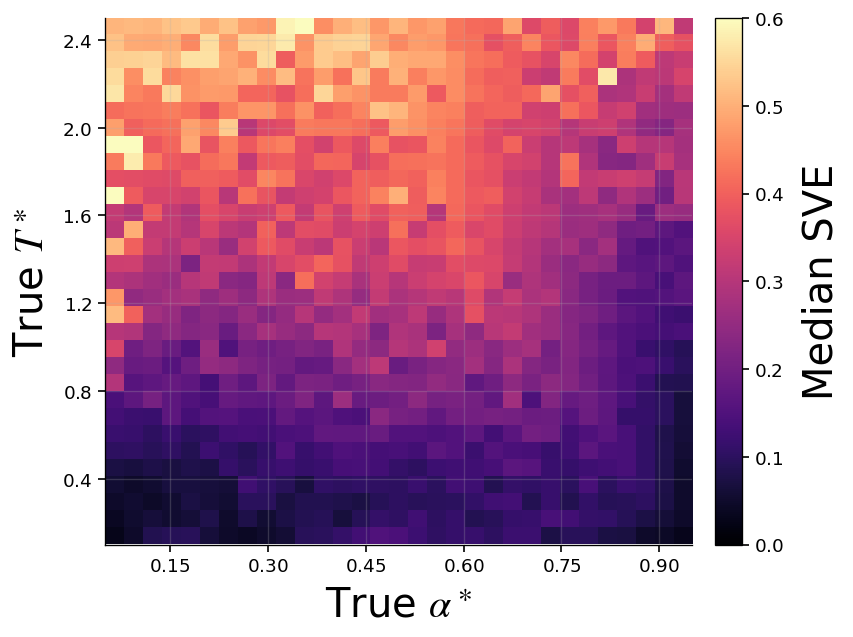

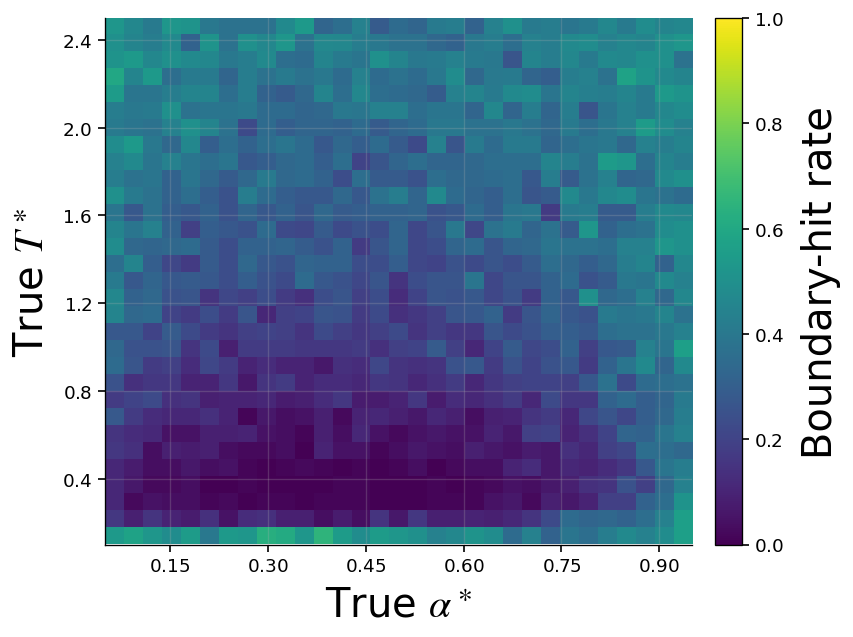

Saved figures:
  artifacts\figures\grid_recovery_median_SVE.png
  artifacts\figures\grid_recovery_boundary_hits.png


In [ ]:
def load_grid_recovery_artifact(config):
    """
    Load saved grid-recovery arrays.
    """
    raw_path = RAW_DIR / f"{config.output_prefix}_raw.npz"
    data = np.load(raw_path)

    return {
        "alpha_grid": data["alpha_grid"],
        "T_grid": data["T_grid"],
        "median_err_scaled": data["median_err_scaled"],
        "p_bound_hit_ok": data["p_bound_hit_ok"],
    }


def plot_grid_median_sve_publication_style(
    grid_results,
    error_clip=0.60,
    err_cmap="magma",
    figsize=(7.0, 5.2),
):
    """
    Plot grid-based median SVE map.

    Visual style intentionally matches the original publication figure.
    """
    alpha_grid = grid_results["alpha_grid"]
    T_grid = grid_results["T_grid"]
    median_err_scaled = grid_results["median_err_scaled"]

    fig, ax = plt.subplots(figsize=figsize)

    Z = np.clip(median_err_scaled, 0.0, float(error_clip))

    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[
            float(alpha_grid.min()),
            float(alpha_grid.max()),
            float(T_grid.min()),
            float(T_grid.max()),
        ],
        cmap=err_cmap,
        vmin=0.0,
        vmax=float(error_clip),
    )

    ax.set_xlabel(r"True $\alpha^\ast$", fontsize=24)
    ax.set_ylabel(r"True $T^\ast$", fontsize=24)

    ax.set_xlim(float(alpha_grid.min()), float(alpha_grid.max()))
    ax.set_ylim(float(T_grid.min()), float(T_grid.max()))
    set_nice_ticks(ax, max_ticks=6)

    cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_label(r"Median SVE", fontsize=24, labelpad=10)

    return fig


def plot_grid_boundary_hits_publication_style(
    grid_results,
    pbound_cmap="viridis",
    figsize=(7.0, 5.2),
):
    """
    Plot grid-based boundary-hit-rate map.

    Visual style intentionally matches the original publication figure.
    """
    alpha_grid = grid_results["alpha_grid"]
    T_grid = grid_results["T_grid"]
    p_bound_hit_ok = grid_results["p_bound_hit_ok"]

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        p_bound_hit_ok,
        origin="lower",
        aspect="auto",
        extent=[
            float(alpha_grid.min()),
            float(alpha_grid.max()),
            float(T_grid.min()),
            float(T_grid.max()),
        ],
        cmap=pbound_cmap,
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_xlabel(r"True $\alpha^\ast$", fontsize=24)
    ax.set_ylabel(r"True $T^\ast$", fontsize=24)

    ax.set_xlim(float(alpha_grid.min()), float(alpha_grid.max()))
    ax.set_ylim(float(T_grid.min()), float(T_grid.max()))
    set_nice_ticks(ax, max_ticks=6)

    cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_label(r"Boundary-hit rate", fontsize=24, labelpad=10)

    return fig


grid_recovery_loaded = load_grid_recovery_artifact(GRID_RECOVERY_EXP)

fig = plot_grid_median_sve_publication_style(grid_recovery_loaded)
save_figure(fig, "grid_recovery_median_SVE.png")
plt.show()

fig = plot_grid_boundary_hits_publication_style(grid_recovery_loaded)
save_figure(fig, "grid_recovery_boundary_hits.png")
plt.show()

print("Saved figures:")
print(" ", FIGURES_DIR / "grid_recovery_median_SVE.png")
print(" ", FIGURES_DIR / "grid_recovery_boundary_hits.png")

The grid-based maps reveal whether recovery quality is uniform across the generating-parameter space. Regions with high median SVE indicate poor recovery, while regions with high boundary-hit rates indicate that estimates are often pushed toward admissible parameter limits.

Unlike classical random-draw recovery, this diagnostic localizes where the model-task-identification setting provides weak or strong support for parameter-based explanation.

### Overlap of recovered parameter distributions

The previous diagnostics evaluated recovery quality over individual parameter values or over a structured grid. We now ask a different question: can two genuinely different generating mechanisms lead to overlapping recovered-parameter distributions?

This is important for explanation. If two regimes generate different subject-level mechanisms but their fitted parameters overlap strongly, then explanations based only on recovered parameters may be unreliable.

This section is split into:

- **HEAVY**: simulate two generating regimes, fit MLE, and save raw artifacts,
- **METRICS**: quantify overlap of recovered distributions,
- **LIGHT**: visualize overlap in recovered parameter space,
- **BONUS**: test whether recovered parameters separate regimes using simple classifiers.

In [29]:
import json
from datetime import datetime, timezone
from dataclasses import dataclass


@dataclass(frozen=True)
class OverlapExperiment:
    """
    Configuration for recovered-parameter overlap analysis.
    """
    n_trials_per_series: int = 80
    n_series_per_regime: int = 800

    alpha_high: float = 0.30
    temperature_high: float = 0.70

    alpha_low: float = 0.10
    temperature_low: float = 0.30

    label_high: str = "higher_alpha_higher_T"
    label_low: str = "lower_alpha_lower_T"

    alpha_init_sd_frac: float = 0.15
    temperature_init_sd_frac: float = 0.15

    output_prefix: str = "overlap_N80_R800_high030_T070_low010_T030"


OVERLAP_EXP = OverlapExperiment()


def run_overlap_regime(theta, n_series, n_trials, rng, init_alpha_sd, init_T_sd):
    """
    Simulate and fit one generating regime.
    """
    alpha_hat = np.full(n_series, np.nan, dtype=float)
    T_hat = np.full(n_series, np.nan, dtype=float)
    ll_hat = np.full(n_series, np.nan, dtype=float)
    success = np.zeros(n_series, dtype=bool)

    bounds = [ALPHA_BOUNDS, T_BOUNDS]

    for i in range(n_series):
        trajectory = simulate_choice_outcome_sequence(
            params=theta,
            n_trials=n_trials,
            rng=rng,
        )

        x0 = random_initial_theta(
            bounds=bounds,
            rng=rng,
            alpha_sd_frac=init_alpha_sd,
            temperature_sd_frac=init_T_sd,
        )

        mle = fit_mle(
            trajectory,
            initial_theta=x0,
        )

        alpha_hat[i] = mle["params"]["alpha"]
        T_hat[i] = mle["params"]["T"]
        ll_hat[i] = mle["log_likelihood"]
        success[i] = mle["success"]

    alpha_on_bound = np.array(
        [is_boundary_hit(x, ALPHA_BOUNDS) for x in alpha_hat],
        dtype=bool,
    )
    T_on_bound = np.array(
        [is_boundary_hit(x, T_BOUNDS) for x in T_hat],
        dtype=bool,
    )
    any_on_bound = alpha_on_bound | T_on_bound

    mask_ok = success & np.isfinite(alpha_hat) & np.isfinite(T_hat)
    mask_interior = mask_ok & (~any_on_bound)

    return {
        "alpha_hat": alpha_hat,
        "T_hat": T_hat,
        "ll_hat": ll_hat,
        "success": success,
        "alpha_on_bound": alpha_on_bound,
        "T_on_bound": T_on_bound,
        "any_on_bound": any_on_bound,
        "mask_ok": mask_ok,
        "mask_interior": mask_interior,
    }


def run_overlap_experiment(config, seed=SEED):
    """
    Run recovered-parameter overlap experiment for two regimes.
    """
    rng = np.random.default_rng(seed)

    theta_high = {
        "alpha": config.alpha_high,
        "T": config.temperature_high,
    }
    theta_low = {
        "alpha": config.alpha_low,
        "T": config.temperature_low,
    }

    res_high = run_overlap_regime(
        theta=theta_high,
        n_series=config.n_series_per_regime,
        n_trials=config.n_trials_per_series,
        rng=rng,
        init_alpha_sd=config.alpha_init_sd_frac,
        init_T_sd=config.temperature_init_sd_frac,
    )

    res_low = run_overlap_regime(
        theta=theta_low,
        n_series=config.n_series_per_regime,
        n_trials=config.n_trials_per_series,
        rng=rng,
        init_alpha_sd=config.alpha_init_sd_frac,
        init_T_sd=config.temperature_init_sd_frac,
    )

    return theta_high, theta_low, res_high, res_low


def summarize_overlap_regime(name, theta, result):
    """
    Print compact summary for one overlap regime.
    """
    mask_ok = result["mask_ok"]
    mask_interior = result["mask_interior"]

    boundary_hit_rate = (
        float(result["any_on_bound"][mask_ok].mean())
        if mask_ok.any()
        else np.nan
    )

    print(f"{name}: alpha*={theta['alpha']:.3f}, T*={theta['T']:.3f}")
    print(f"  successful finite fits: {int(mask_ok.sum())}/{len(mask_ok)}")
    print(f"  interior fits:          {int(mask_interior.sum())}/{len(mask_interior)}")
    print(f"  boundary-hit rate:      {boundary_hit_rate:.3f}")


def save_overlap_artifacts(config, theta_high, theta_low, res_high, res_low):
    """
    Save overlap raw arrays and metadata.
    """
    raw_path = RAW_DIR / f"{config.output_prefix}_raw.npz"
    meta_path = METADATA_DIR / f"{config.output_prefix}_metadata.json"

    display_label_high = r"higher $\alpha^\ast$, higher $T^\ast$"
    display_label_low = r"lower $\alpha^\ast$, lower $T^\ast$"

    np.savez_compressed(
        raw_path,
        n_trials=int(config.n_trials_per_series),
        n_series=int(config.n_series_per_regime),
        alpha_bounds=np.array(ALPHA_BOUNDS, dtype=float),
        T_bounds=np.array(T_BOUNDS, dtype=float),
        bound_tol=float(BOUNDARY_TOL),

        label_H=config.label_high,
        label_L=config.label_low,
        display_label_H=display_label_high,
        display_label_L=display_label_low,

        alpha_true_H=float(theta_high["alpha"]),
        T_true_H=float(theta_high["T"]),
        alpha_true_L=float(theta_low["alpha"]),
        T_true_L=float(theta_low["T"]),

        alpha_hat_H=res_high["alpha_hat"],
        T_hat_H=res_high["T_hat"],
        ll_hat_H=res_high["ll_hat"],
        success_H=res_high["success"],
        any_on_bound_H=res_high["any_on_bound"],

        alpha_hat_L=res_low["alpha_hat"],
        T_hat_L=res_low["T_hat"],
        ll_hat_L=res_low["ll_hat"],
        success_L=res_low["success"],
        any_on_bound_L=res_low["any_on_bound"],
    )

    metadata = {
        "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "seed": int(SEED),
        "design": {
            "n_trials_per_series": int(config.n_trials_per_series),
            "n_series_per_regime": int(config.n_series_per_regime),
            "p_reward_A": float(P_REWARD_A),
            "p_reward_B": float(P_REWARD_B),
        },
        "regimes": {
            "H": {
                "label": config.label_high,
                "display_label": display_label_high,
                "alpha": float(theta_high["alpha"]),
                "T": float(theta_high["T"]),
            },
            "L": {
                "label": config.label_low,
                "display_label": display_label_low,
                "alpha": float(theta_low["alpha"]),
                "T": float(theta_low["T"]),
            },
        },
        "mle": {
            "alpha_bounds": list(map(float, ALPHA_BOUNDS)),
            "T_bounds": list(map(float, T_BOUNDS)),
            "init_sd_frac_alpha": float(config.alpha_init_sd_frac),
            "init_sd_frac_T": float(config.temperature_init_sd_frac),
            "bound_tol": float(BOUNDARY_TOL),
            "optimizer": CONFIG.identification.optimizer,
        },
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    return raw_path, meta_path


theta_H, theta_L, res_H, res_L = run_overlap_experiment(
    OVERLAP_EXP,
    seed=SEED,
)

print("Overlap dataset: two generating regimes")
print(f"  trials per sequence: {OVERLAP_EXP.n_trials_per_series}")
print(f"  sequences per regime: {OVERLAP_EXP.n_series_per_regime}")

summarize_overlap_regime("Regime H", theta_H, res_H)
summarize_overlap_regime("Regime L", theta_L, res_L)

raw_path, meta_path = save_overlap_artifacts(
    OVERLAP_EXP,
    theta_H,
    theta_L,
    res_H,
    res_L,
)

print("\nSaved raw data:", raw_path)
print("Saved metadata:", meta_path)

Overlap dataset: two generating regimes
  trials per sequence: 80
  sequences per regime: 800
Regime H: alpha*=0.300, T*=0.700
  successful finite fits: 800/800
  interior fits:          727/800
  boundary-hit rate:      0.091
Regime L: alpha*=0.100, T*=0.300
  successful finite fits: 800/800
  interior fits:          777/800
  boundary-hit rate:      0.029

Saved raw data: artifacts\raw\overlap_N80_R800_high030_T070_low010_T030_raw.npz
Saved metadata: artifacts\metadata\overlap_N80_R800_high030_T070_low010_T030_metadata.json


#### Overlap metrics

The figure below provides a visual diagnostic, but we also quantify overlap between recovered-parameter distributions.

We compute two density-based summaries:

- the density overlap coefficient,
- the Jensen–Shannon divergence.

Metrics are computed both for interior fits and for all successful finite fits.

In [30]:
from scipy.stats import gaussian_kde


@dataclass(frozen=True)
class OverlapMetricsConfig:
    """
    Configuration for KDE-based overlap metrics.
    """
    xlim: tuple[float, float] = (0.0, 1.0)
    ylim: tuple[float, float] = (0.0, 3.0)
    grid_n_alpha: int = 220
    grid_n_T: int = 220
    kde_bw_method: object = None
    eps: float = 1e-12


OVERLAP_METRICS_CONFIG = OverlapMetricsConfig()


def load_overlap_artifact(config):
    """
    Load saved overlap artifact.
    """
    raw_path = RAW_DIR / f"{config.output_prefix}_raw.npz"
    d = np.load(raw_path, allow_pickle=True)
    return d


def kde_grid(x, y, xlim, ylim, nx, ny, bw_method=None):
    """
    Evaluate a 2D KDE on a regular grid.
    """
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=bw_method)

    xg = np.linspace(float(xlim[0]), float(xlim[1]), int(nx))
    yg = np.linspace(float(ylim[0]), float(ylim[1]), int(ny))

    X, Y = np.meshgrid(xg, yg)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(Y.shape)

    return X, Y, Z


def normalize_to_probability_grid(Z):
    """
    Normalize non-negative grid values to sum to one.
    """
    Z = np.asarray(Z, dtype=float)
    total = float(Z.sum())

    if total <= 0.0:
        raise ValueError("KDE grid has non-positive total density.")

    return Z / total


def density_overlap_coefficient(P, Q):
    """
    Compute density overlap coefficient between two probability grids.
    """
    return float(np.minimum(P, Q).sum())


def jensen_shannon_divergence(P, Q, eps=1e-12):
    """
    Compute Jensen-Shannon divergence between two probability grids.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    P = np.maximum(P, eps)
    Q = np.maximum(Q, eps)

    P = P / P.sum()
    Q = Q / Q.sum()

    M = 0.5 * (P + Q)

    kl_PM = float(np.sum(P * (np.log(P) - np.log(M))))
    kl_QM = float(np.sum(Q * (np.log(Q) - np.log(M))))

    return 0.5 * (kl_PM + kl_QM)


def compute_overlap_metrics(xH, yH, xL, yL, tag, metrics_config):
    """
    Compute KDE-based overlap metrics for two recovered-parameter clouds.
    """
    if xH.size <= 10 or xL.size <= 10:
        raise ValueError(f"Too few points for KDE overlap metrics: {tag}")

    _, _, ZH = kde_grid(
        xH,
        yH,
        xlim=metrics_config.xlim,
        ylim=metrics_config.ylim,
        nx=metrics_config.grid_n_alpha,
        ny=metrics_config.grid_n_T,
        bw_method=metrics_config.kde_bw_method,
    )

    _, _, ZL = kde_grid(
        xL,
        yL,
        xlim=metrics_config.xlim,
        ylim=metrics_config.ylim,
        nx=metrics_config.grid_n_alpha,
        ny=metrics_config.grid_n_T,
        bw_method=metrics_config.kde_bw_method,
    )

    PH = normalize_to_probability_grid(ZH)
    PL = normalize_to_probability_grid(ZL)

    return {
        "tag": tag,
        "n_H": int(xH.size),
        "n_L": int(xL.size),
        "O": density_overlap_coefficient(PH, PL),
        "JSD": jensen_shannon_divergence(PH, PL, eps=metrics_config.eps),
    }


def compute_and_save_overlap_metrics(experiment_config, metrics_config):
    """
    Compute overlap metrics from saved raw artifact and save JSON.
    """
    d = load_overlap_artifact(experiment_config)

    alpha_hat_H = np.asarray(d["alpha_hat_H"], dtype=float)
    T_hat_H = np.asarray(d["T_hat_H"], dtype=float)
    success_H = np.asarray(d["success_H"], dtype=bool)
    any_on_bound_H = np.asarray(d["any_on_bound_H"], dtype=bool)

    alpha_hat_L = np.asarray(d["alpha_hat_L"], dtype=float)
    T_hat_L = np.asarray(d["T_hat_L"], dtype=float)
    success_L = np.asarray(d["success_L"], dtype=bool)
    any_on_bound_L = np.asarray(d["any_on_bound_L"], dtype=bool)

    alpha_true_H = float(d["alpha_true_H"])
    T_true_H = float(d["T_true_H"])
    alpha_true_L = float(d["alpha_true_L"])
    T_true_L = float(d["T_true_L"])

    n_trials = int(d["n_trials"])
    n_series = int(d["n_series"])

    mask_H_ok = success_H & np.isfinite(alpha_hat_H) & np.isfinite(T_hat_H)
    mask_L_ok = success_L & np.isfinite(alpha_hat_L) & np.isfinite(T_hat_L)

    mask_H_interior = mask_H_ok & (~any_on_bound_H)
    mask_L_interior = mask_L_ok & (~any_on_bound_L)

    metrics_interior = compute_overlap_metrics(
        alpha_hat_H[mask_H_interior],
        T_hat_H[mask_H_interior],
        alpha_hat_L[mask_L_interior],
        T_hat_L[mask_L_interior],
        tag="interior fits",
        metrics_config=metrics_config,
    )

    metrics_ok = compute_overlap_metrics(
        alpha_hat_H[mask_H_ok],
        T_hat_H[mask_H_ok],
        alpha_hat_L[mask_L_ok],
        T_hat_L[mask_L_ok],
        tag="successful finite fits",
        metrics_config=metrics_config,
    )

    metrics = {
        "raw_path": str(RAW_DIR / f"{experiment_config.output_prefix}_raw.npz"),
        "support": {
            "xlim": list(map(float, metrics_config.xlim)),
            "ylim": list(map(float, metrics_config.ylim)),
            "grid_n_alpha": int(metrics_config.grid_n_alpha),
            "grid_n_T": int(metrics_config.grid_n_T),
            "kde_bw_method": (
                "Scott default"
                if metrics_config.kde_bw_method is None
                else str(metrics_config.kde_bw_method)
            ),
        },
        "regimes": {
            "H": {"alpha": alpha_true_H, "T": T_true_H},
            "L": {"alpha": alpha_true_L, "T": T_true_L},
        },
        "design": {
            "n_series_per_regime": n_series,
            "n_trials": n_trials,
        },
        "interior": metrics_interior,
        "ok": metrics_ok,
    }

    metrics_path = METRICS_DIR / f"{experiment_config.output_prefix}_metrics.json"

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    print("Overlap metrics based on KDE densities")
    print(
        f"  regimes: H=({alpha_true_H:.3f}, {T_true_H:.3f}), "
        f"L=({alpha_true_L:.3f}, {T_true_L:.3f})"
    )
    print(f"  sequences per regime: {n_series}, sequence length: {n_trials}")
    print()

    for m in [metrics_interior, metrics_ok]:
        print(f"{m['tag']}:")
        print(f"  n_H = {m['n_H']}, n_L = {m['n_L']}")
        print(f"  density overlap coefficient O = {m['O']:.3f}")
        print(f"  Jensen-Shannon divergence JSD = {m['JSD']:.3f}")
        print()

    print("Saved metrics:", metrics_path)

    return metrics


overlap_metrics = compute_and_save_overlap_metrics(
    OVERLAP_EXP,
    OVERLAP_METRICS_CONFIG,
)

Overlap metrics based on KDE densities
  regimes: H=(0.300, 0.700), L=(0.100, 0.300)
  sequences per regime: 800, sequence length: 80

interior fits:
  n_H = 727, n_L = 777
  density overlap coefficient O = 0.263
  Jensen-Shannon divergence JSD = 0.370

successful finite fits:
  n_H = 800, n_L = 800
  density overlap coefficient O = 0.312
  Jensen-Shannon divergence JSD = 0.328

Saved metrics: artifacts\metrics\overlap_N80_R800_high030_T070_low010_T030_metrics.json


#### Recovered-parameter overlap figure

The following figure visualizes the recovered parameter distributions for the two regimes. The true generating points are separated, but the fitted parameter clouds may overlap.

This is the central XAI-related diagnostic: if recovered parameters are used as explanations, overlap in recovered space can make distinct generating mechanisms appear less distinguishable.

Overlap figure summary:
  raw data: artifacts\raw\overlap_N80_R800_high030_T070_low010_T030_raw.npz
  sequences per regime: 800, sequence length: 80
  plotted interior fits: H=727, L=777
  density overlap coefficient O = 0.263
  Jensen-Shannon divergence JSD = 0.370


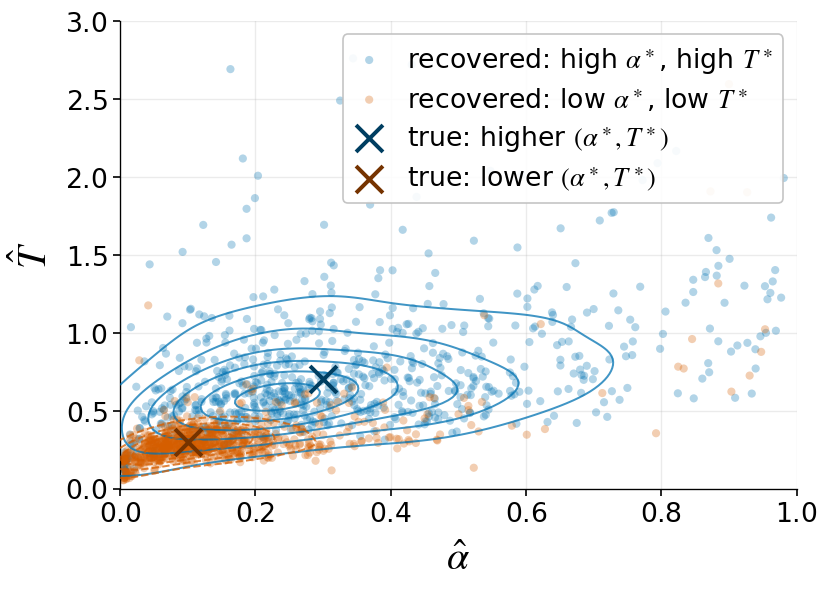

In [31]:
def darken_hex(hex_color, factor=0.55):
    h = hex_color.lstrip("#")
    r = int(h[0:2], 16)
    g = int(h[2:4], 16)
    b = int(h[4:6], 16)

    r = int(np.clip(r * factor, 0, 255))
    g = int(np.clip(g * factor, 0, 255))
    b = int(np.clip(b * factor, 0, 255))

    return f"#{r:02X}{g:02X}{b:02X}"


def kde_on_grid(x, y, xlim, ylim, nx, ny, bw_method=None):
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=bw_method)

    xg = np.linspace(float(xlim[0]), float(xlim[1]), int(nx))
    yg = np.linspace(float(ylim[0]), float(ylim[1]), int(ny))

    X, Y = np.meshgrid(xg, yg)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(Y.shape)

    return X, Y, Z


def contour_levels(Z, n_levels=6):
    zmax = float(np.max(Z))
    zmin = float(np.min(Z))

    lo = zmin + 0.15 * (zmax - zmin)
    hi = zmin + 0.92 * (zmax - zmin)

    return np.linspace(lo, hi, int(n_levels))


def plot_overlap_recovered_parameter_space_publication_style(
    experiment_config,
    metrics_config,
):
    """
    Plot recovered-parameter overlap.

    Visual style intentionally matches the original publication figure.
    """
    raw_path = RAW_DIR / f"{experiment_config.output_prefix}_raw.npz"
    metrics_path = METRICS_DIR / f"{experiment_config.output_prefix}_metrics.json"

    d = np.load(raw_path, allow_pickle=True)

    alpha_hat_H = np.asarray(d["alpha_hat_H"], dtype=float)
    T_hat_H = np.asarray(d["T_hat_H"], dtype=float)
    success_H = np.asarray(d["success_H"], dtype=bool)
    any_on_bound_H = np.asarray(d["any_on_bound_H"], dtype=bool)

    alpha_hat_L = np.asarray(d["alpha_hat_L"], dtype=float)
    T_hat_L = np.asarray(d["T_hat_L"], dtype=float)
    success_L = np.asarray(d["success_L"], dtype=bool)
    any_on_bound_L = np.asarray(d["any_on_bound_L"], dtype=bool)

    alpha_true_H = float(d["alpha_true_H"])
    T_true_H = float(d["T_true_H"])
    alpha_true_L = float(d["alpha_true_L"])
    T_true_L = float(d["T_true_L"])

    n_trials = int(d["n_trials"])
    n_series = int(d["n_series"])

    mask_H = success_H & np.isfinite(alpha_hat_H) & np.isfinite(T_hat_H) & (~any_on_bound_H)
    mask_L = success_L & np.isfinite(alpha_hat_L) & np.isfinite(T_hat_L) & (~any_on_bound_L)

    xH, yH = alpha_hat_H[mask_H], T_hat_H[mask_H]
    xL, yL = alpha_hat_L[mask_L], T_hat_L[mask_L]

    try:
        with open(metrics_path, "r", encoding="utf-8") as f:
            metrics = json.load(f)

        O_interior = float(metrics["interior"]["O"])
        JSD_interior = float(metrics["interior"]["JSD"])
    except FileNotFoundError:
        O_interior = np.nan
        JSD_interior = np.nan

    xlim = metrics_config.xlim
    ylim = metrics_config.ylim

    point_size = 24
    point_alpha = 0.3
    marker = "o"
    rasterize_points = True

    grid_n_alpha = 160
    grid_n_T = 160
    kde_bw_method = None
    kde_min_points = 80
    n_levels = 6
    contour_lw = 1.2
    contour_alpha = 0.75

    label_fs = 24
    tick_fs = 16
    legend_fs = 16

    color_H = "#0072B2"
    color_L = "#D55E00"

    color_H_true = darken_hex(color_H, factor=0.55)
    color_L_true = darken_hex(color_L, factor=0.55)

    fig, ax = plt.subplots(figsize=(6.8, 4.8), layout="constrained")

    rec_H = ax.scatter(
        xH,
        yH,
        s=point_size,
        marker=marker,
        alpha=point_alpha,
        c=color_H,
        edgecolors="none",
        rasterized=rasterize_points,
        label=r"recovered: high $\alpha^\ast$, high $T^\ast$",
        zorder=1,
    )

    rec_L = ax.scatter(
        xL,
        yL,
        s=point_size,
        marker=marker,
        alpha=point_alpha,
        c=color_L,
        edgecolors="none",
        rasterized=rasterize_points,
        label=r"recovered: low $\alpha^\ast$, low $T^\ast$",
        zorder=1,
    )

    if xH.size >= kde_min_points:
        XH, YH, ZH = kde_on_grid(
            xH,
            yH,
            xlim=xlim,
            ylim=ylim,
            nx=grid_n_alpha,
            ny=grid_n_T,
            bw_method=kde_bw_method,
        )
        ax.contour(
            XH,
            YH,
            ZH,
            levels=contour_levels(ZH, n_levels=n_levels),
            colors=[color_H],
            linewidths=contour_lw,
            alpha=contour_alpha,
            linestyles="-",
            zorder=3,
        )

    if xL.size >= kde_min_points:
        XL, YL, ZL = kde_on_grid(
            xL,
            yL,
            xlim=xlim,
            ylim=ylim,
            nx=grid_n_alpha,
            ny=grid_n_T,
            bw_method=kde_bw_method,
        )
        ax.contour(
            XL,
            YL,
            ZL,
            levels=contour_levels(ZL, n_levels=n_levels),
            colors=[color_L],
            linewidths=contour_lw,
            alpha=contour_alpha,
            linestyles="--",
            zorder=3,
        )

    true_H = ax.scatter(
        [alpha_true_H],
        [T_true_H],
        marker="x",
        s=260,
        c=color_H_true,
        linewidths=2.4,
        label=r"true: higher $(\alpha^\ast,T^\ast)$",
        zorder=4,
    )

    true_L = ax.scatter(
        [alpha_true_L],
        [T_true_L],
        marker="x",
        s=260,
        c=color_L_true,
        linewidths=2.4,
        label=r"true: lower $(\alpha^\ast,T^\ast)$",
        zorder=4,
    )

    ax.set_xlabel(r"$\hat{\alpha}$", fontsize=label_fs)
    ax.set_ylabel(r"$\hat{T}$", fontsize=label_fs)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="both", labelsize=tick_fs)
    set_nice_ticks(ax, max_ticks=6)

    ax.legend(
        handles=[rec_H, rec_L, true_H, true_L],
        loc="upper right",
        frameon=True,
        fancybox=True,
        framealpha=0.90,
        edgecolor="0.75",
        facecolor="white",
        fontsize=legend_fs,
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
    )

    print("Overlap figure summary:")
    print(f"  raw data: {raw_path}")
    print(f"  sequences per regime: {n_series}, sequence length: {n_trials}")
    print(f"  plotted interior fits: H={int(mask_H.sum())}, L={int(mask_L.sum())}")
    print(f"  density overlap coefficient O = {O_interior:.3f}")
    print(f"  Jensen-Shannon divergence JSD = {JSD_interior:.3f}")

    return fig


fig = plot_overlap_recovered_parameter_space_publication_style(
    OVERLAP_EXP,
    OVERLAP_METRICS_CONFIG,
)

save_figure(fig, "overlap_recovered_parameter_space.png")
plt.show()

#### Bonus: separability of regimes from recovered parameters

This analysis is not part of the main figure set. It is included as an exploratory extension for future work.

If recovered parameters are used as explanatory features, then one may ask whether two generating regimes are separable in recovered-parameter space. Here we test this with a simple linear classifier and, optionally, a random forest sanity check.

This does not replace the overlap analysis. It provides a complementary predictive view of the same question.

In [32]:
def load_overlap_classification_dataset(experiment_config):
    """
    Build a classification dataset from the overlap artifact.
    """
    raw_path = RAW_DIR / f"{experiment_config.output_prefix}_raw.npz"
    d = np.load(raw_path, allow_pickle=True)

    alpha_hat_H = np.asarray(d["alpha_hat_H"], dtype=float)
    T_hat_H = np.asarray(d["T_hat_H"], dtype=float)
    success_H = np.asarray(d["success_H"], dtype=bool)
    any_on_bound_H = np.asarray(d["any_on_bound_H"], dtype=bool)

    alpha_hat_L = np.asarray(d["alpha_hat_L"], dtype=float)
    T_hat_L = np.asarray(d["T_hat_L"], dtype=float)
    success_L = np.asarray(d["success_L"], dtype=bool)
    any_on_bound_L = np.asarray(d["any_on_bound_L"], dtype=bool)

    mask_H = success_H & np.isfinite(alpha_hat_H) & np.isfinite(T_hat_H) & (~any_on_bound_H)
    mask_L = success_L & np.isfinite(alpha_hat_L) & np.isfinite(T_hat_L) & (~any_on_bound_L)

    XH = np.column_stack([alpha_hat_H[mask_H], T_hat_H[mask_H]])
    XL = np.column_stack([alpha_hat_L[mask_L], T_hat_L[mask_L]])

    X = np.vstack([XH, XL])
    y = np.concatenate([
        np.zeros(XH.shape[0], dtype=int),
        np.ones(XL.shape[0], dtype=int),
    ])

    return X, y, XH.shape[0], XL.shape[0], raw_path


def evaluate_overlap_separability(
    experiment_config,
    n_splits=5,
    shuffle=True,
    random_state=2025,
    use_random_forest=True,
):
    """
    Evaluate whether recovered parameters separate the two regimes.
    """
    from sklearn.model_selection import StratifiedKFold
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score

    X, y, n_H, n_L, raw_path = load_overlap_classification_dataset(
        experiment_config
    )

    print("XAI separability dataset (interior only):")
    print(f"  raw_path: {raw_path}")
    print(f"  H={experiment_config.label_high}: n={n_H}")
    print(f"  L={experiment_config.label_low}: n={n_L}")
    print()

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=shuffle,
        random_state=random_state,
    )

    logit = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=2000,
                ),
            ),
        ]
    )

    auc_logit = []

    for train_idx, test_idx in cv.split(X, y):
        logit.fit(X[train_idx], y[train_idx])
        scores = logit.predict_proba(X[test_idx])[:, 1]
        auc_logit.append(float(roc_auc_score(y[test_idx], scores)))

    print("AUC (StratifiedKFold CV):")
    print(
        "  LogisticRegression (linear): "
        f"mean={np.mean(auc_logit):.3f}, "
        f"sd={np.std(auc_logit):.3f} | folds={auc_logit}"
    )

    results = {
        "logistic_auc_mean": float(np.mean(auc_logit)),
        "logistic_auc_sd": float(np.std(auc_logit)),
        "logistic_auc_folds": auc_logit,
    }

    if use_random_forest:
        from sklearn.ensemble import RandomForestClassifier

        rf = RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=10,
            random_state=random_state,
            n_jobs=-1,
        )

        auc_rf = []

        for train_idx, test_idx in cv.split(X, y):
            rf.fit(X[train_idx], y[train_idx])
            scores = rf.predict_proba(X[test_idx])[:, 1]
            auc_rf.append(float(roc_auc_score(y[test_idx], scores)))

        print(
            "  RandomForest (sanity check): "
            f"mean={np.mean(auc_rf):.3f}, "
            f"sd={np.std(auc_rf):.3f} | folds={auc_rf}"
        )

        results["random_forest_auc_mean"] = float(np.mean(auc_rf))
        results["random_forest_auc_sd"] = float(np.std(auc_rf))
        results["random_forest_auc_folds"] = auc_rf

    return results


xai_separability_results = evaluate_overlap_separability(
    OVERLAP_EXP,
    n_splits=5,
    random_state=2025,
    use_random_forest=True,
)

XAI separability dataset (interior only):
  raw_path: artifacts\raw\overlap_N80_R800_high030_T070_low010_T030_raw.npz
  H=higher_alpha_higher_T: n=727
  L=lower_alpha_lower_T: n=777

AUC (StratifiedKFold CV):
  LogisticRegression (linear): mean=0.930, sd=0.008 | folds=[0.9368537339814406, 0.9305346884666372, 0.9392130857648101, 0.924845269672856, 0.9183982202447165]
  RandomForest (sanity check): mean=0.947, sd=0.009 | folds=[0.9421564295183386, 0.9636765355722492, 0.9402298850574713, 0.9382404951370469, 0.9512347052280312]
